# Smart AI Retail System

## PHASE 0 — DATA RECONNAISSANCE

### Step 0.1 Source File Validation

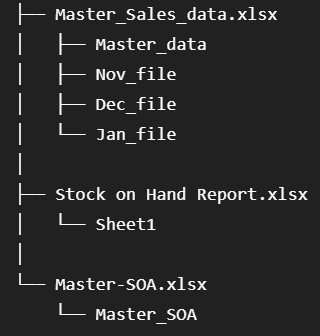


### Step 0.2 — Master Sales Data Profiling

**Objective**

Profile the raw `Master_Sales_data.xlsx` workbook before any cleaning or
transformation is performed.

This notebook will examine:

- Workbook structure
- Sheet dimensions
- Column consistency
- Data types
- Missing values
- Duplicate records and duplicate product keys
- Negative stock levels
- Basic numerical integrity
- Relationship between Master_data and monthly snapshots

In [2]:
### Import libraries
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

SALES_FILE = RAW_DATA_DIR / "Master_Sales_data.xlsx"
STOCK_FILE = RAW_DATA_DIR / "Stock on Hand Report.xlsx"
SOA_FILE = RAW_DATA_DIR / "Master-SOA.xlsx"

print("Project root :", PROJECT_ROOT)
print("Raw data dir :", RAW_DATA_DIR)

print("\nSource files:")
print("Sales :", SALES_FILE)
print("Stock :", STOCK_FILE)
print("SOA   :", SOA_FILE)

Project root : d:\STUDY\Data_Science_Courses\PROJECTS\12.Smart_AI-Retail_System\Smart_AI_Retail_System
Raw data dir : d:\STUDY\Data_Science_Courses\PROJECTS\12.Smart_AI-Retail_System\Smart_AI_Retail_System\data\raw

Source files:
Sales : d:\STUDY\Data_Science_Courses\PROJECTS\12.Smart_AI-Retail_System\Smart_AI_Retail_System\data\raw\Master_Sales_data.xlsx
Stock : d:\STUDY\Data_Science_Courses\PROJECTS\12.Smart_AI-Retail_System\Smart_AI_Retail_System\data\raw\Stock on Hand Report.xlsx
SOA   : d:\STUDY\Data_Science_Courses\PROJECTS\12.Smart_AI-Retail_System\Smart_AI_Retail_System\data\raw\Master-SOA.xlsx


In [4]:
source_files = {
    "Master Sales": SALES_FILE,
    "Stock on Hand": STOCK_FILE,
    "Master SOA": SOA_FILE
}

for name, path in source_files.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name:<20} : {status}")

Master Sales         : FOUND
Stock on Hand        : FOUND
Master SOA           : FOUND


In [5]:
sales_excel = pd.ExcelFile(SALES_FILE)

print("Sheets found in Master_Sales_data.xlsx:")
for sheet in sales_excel.sheet_names:
    print(f" - {sheet}")

Sheets found in Master_Sales_data.xlsx:
 - Master_data
 - Nov_file
 - Dec_file
 - Jan_file


#### Step 0.2.1 — Load all four sheets

In [6]:
sales_sheets = pd.read_excel(
    SALES_FILE,
    sheet_name=None
)

print(f"Number of sheets loaded: {len(sales_sheets)}")

for sheet_name, df in sales_sheets.items():
    print(
        f"{sheet_name:<15} "
        f"Rows: {df.shape[0]:>4} | "
        f"Columns: {df.shape[1]:>2}"
    )

Number of sheets loaded: 4
Master_data     Rows:  966 | Columns: 11
Nov_file        Rows:  381 | Columns: 11
Dec_file        Rows:  323 | Columns: 11
Jan_file        Rows:  262 | Columns: 11


In [7]:
for sheet_name, df in sales_sheets.items():

    print(f"\n{'=' * 60}")
    print(f"SHEET: {sheet_name}")
    print(f"{'=' * 60}")

    print(df.columns.tolist())


SHEET: Master_data
['Category', 'Stock Code', 'Description', 'Level', 'Sold Period', 'Unit Cost', 'Unit Price', 'Cost Sales', 'Sales Value', 'Profit', 'Profit %']

SHEET: Nov_file
['Category', 'Stock Code', 'Description', 'Level', 'Sold Period', 'Unit Cost', 'Unit Price', 'Cost Sales', 'Sales Value', 'Profit', 'Profit %']

SHEET: Dec_file
['Category', 'Stock Code', 'Description', 'Level', 'Sold Period', 'Unit Cost', 'Unit Price', 'Cost Sales', 'Sales Value', 'Profit', 'Profit %']

SHEET: Jan_file
['Category', 'Stock Code', 'Description', 'Level', 'Sold Period', 'Unit Cost', 'Unit Price', 'Cost Sales', 'Sales Value', 'Profit', 'Profit %']


#### Step 0.2.2 — Verify column consistency

In [8]:
reference_columns = list(sales_sheets["Master_data"].columns)

column_validation = []

for sheet_name, df in sales_sheets.items():

    columns_match = list(df.columns) == reference_columns

    column_validation.append({
        "Sheet": sheet_name,
        "Column_Count": len(df.columns),
        "Matches_Master_Schema": columns_match
    })

column_validation_df = pd.DataFrame(column_validation)

column_validation_df

,Sheet,Column_Count,Matches_Master_Schema
0,Master_data,11,True
1,Nov_file,11,True
2,Dec_file,11,True
3,Jan_file,11,True


#### Step 0.2.3 — Data Types & Missing Values

In [9]:
for sheet_name, df in sales_sheets.items():

    print(f"\n{'=' * 65}")
    print(f"DATA TYPES — {sheet_name}")
    print(f"{'=' * 65}")

    print(df.dtypes)


DATA TYPES — Master_data
Category        object
Stock Code      object
Description     object
Level            int64
Sold Period      int64
Unit Cost      float64
Unit Price     float64
Cost Sales     float64
Sales Value    float64
Profit         float64
Profit %       float64
dtype: object

DATA TYPES — Nov_file
Category        object
Stock Code      object
Description     object
Level            int64
Sold Period      int64
Unit Cost      float64
Unit Price     float64
Cost Sales     float64
Sales Value    float64
Profit         float64
Profit %       float64
dtype: object

DATA TYPES — Dec_file
Category        object
Stock Code      object
Description     object
Level            int64
Sold Period      int64
Unit Cost      float64
Unit Price     float64
Cost Sales     float64
Sales Value    float64
Profit         float64
Profit %       float64
dtype: object

DATA TYPES — Jan_file
Category        object
Stock Code      object
Description     object
Level            int64
Sold Period 

In [10]:
dtype_comparison = pd.DataFrame({
    sheet_name: df.dtypes.astype(str)
    for sheet_name, df in sales_sheets.items()
})

dtype_comparison

,Master_data,Nov_file,Dec_file,Jan_file
Category,object,object,object,object
Stock Code,object,object,object,object
Description,object,object,object,object
Level,int64,int64,int64,int64
Sold Period,int64,int64,int64,int64
Unit Cost,float64,float64,float64,float64
Unit Price,float64,float64,float64,float64
Cost Sales,float64,float64,float64,float64
Sales Value,float64,float64,float64,float64
Profit,float64,float64,float64,float64


#### Step 0.2.4 — Missing-value profiling

In [11]:
for sheet_name, df in sales_sheets.items():

    print(f"\n{'=' * 65}")
    print(f"MISSING VALUES — {sheet_name}")
    print(f"{'=' * 65}")

    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df) * 100).round(2)

    missing_summary = pd.DataFrame({
        "Missing_Count": missing_count,
        "Missing_Percent": missing_pct
    })

    print(missing_summary)


MISSING VALUES — Master_data
             Missing_Count  Missing_Percent
Category                 0              0.0
Stock Code               0              0.0
Description              0              0.0
Level                    0              0.0
Sold Period              0              0.0
Unit Cost                0              0.0
Unit Price               0              0.0
Cost Sales               0              0.0
Sales Value              0              0.0
Profit                   0              0.0
Profit %                 0              0.0

MISSING VALUES — Nov_file
             Missing_Count  Missing_Percent
Category                 0              0.0
Stock Code               0              0.0
Description              0              0.0
Level                    0              0.0
Sold Period              0              0.0
Unit Cost                0              0.0
Unit Price               0              0.0
Cost Sales               0              0.0
Sales Value        

In [12]:
missing_comparison = pd.DataFrame({
    sheet_name: df.isnull().sum()
    for sheet_name, df in sales_sheets.items()
})

missing_comparison

,Master_data,Nov_file,Dec_file,Jan_file
Category,0,0,0,0
Stock Code,0,0,0,0
Description,0,0,0,0
Level,0,0,0,0
Sold Period,0,0,0,0
Unit Cost,0,0,0,0
Unit Price,0,0,0,0
Cost Sales,0,0,0,0
Sales Value,0,0,0,0
Profit,0,0,0,0


In [13]:
empty_row_summary = []

for sheet_name, df in sales_sheets.items():

    empty_rows = df.isnull().all(axis=1).sum()

    empty_row_summary.append({
        "Sheet": sheet_name,
        "Total_Rows": len(df),
        "Completely_Empty_Rows": empty_rows
    })

empty_row_summary_df = pd.DataFrame(empty_row_summary)

empty_row_summary_df

,Sheet,Total_Rows,Completely_Empty_Rows
0,Master_data,966,0
1,Nov_file,381,0
2,Dec_file,323,0
3,Jan_file,262,0


#### Step 0.2.5 — Basic completeness of critical fields

In [14]:
critical_columns = [
    "Category",
    "Stock Code",
    "Description",
    "Sold Period",
    "Unit Cost",
    "Unit Price",
    "Sales Value",
    "Profit"
]

critical_missing_summary = []

for sheet_name, df in sales_sheets.items():

    for column in critical_columns:

        missing_count = df[column].isnull().sum()

        critical_missing_summary.append({
            "Sheet": sheet_name,
            "Column": column,
            "Missing_Count": missing_count,
            "Missing_Percent": round(
                missing_count / len(df) * 100, 2
            )
        })

critical_missing_df = pd.DataFrame(critical_missing_summary)

critical_missing_df[
    critical_missing_df["Missing_Count"] > 0
]

,Sheet,Column,Missing_Count,Missing_Percent


#### Step 0.2.6 — Duplicate Analysis

In [15]:
duplicate_row_summary = []

for sheet_name, df in sales_sheets.items():

    duplicate_count = df.duplicated().sum()

    duplicate_row_summary.append({
        "Sheet": sheet_name,
        "Total_Rows": len(df),
        "Exact_Duplicate_Rows": duplicate_count,
        "Duplicate_Percent": round(
            duplicate_count / len(df) * 100, 2
        )
    })

duplicate_row_summary_df = pd.DataFrame(duplicate_row_summary)

duplicate_row_summary_df

,Sheet,Total_Rows,Exact_Duplicate_Rows,Duplicate_Percent
0,Master_data,966,39,4.04
1,Nov_file,381,0,0.00
2,Dec_file,323,0,0.00
3,Jan_file,262,0,0.00


#### Step 0.2.7 — Duplicate Stock Codes

In [16]:
stock_code_summary = []

for sheet_name, df in sales_sheets.items():

    total_rows = len(df)
    unique_stock_codes = df["Stock Code"].nunique()
    duplicate_stock_code_rows = df.duplicated(
        subset=["Stock Code"],
        keep=False
    ).sum()

    stock_code_summary.append({
        "Sheet": sheet_name,
        "Total_Rows": total_rows,
        "Unique_Stock_Codes": unique_stock_codes,
        "Rows_With_Duplicated_Stock_Code": duplicate_stock_code_rows
    })

stock_code_summary_df = pd.DataFrame(stock_code_summary)

stock_code_summary_df

,Sheet,Total_Rows,Unique_Stock_Codes,Rows_With_Duplicated_Stock_Code
0,Master_data,966,768,365
1,Nov_file,381,381,0
2,Dec_file,323,319,7
3,Jan_file,262,262,0


#### Step 0.2.8 — Inspect the duplicated SKUs

In [17]:
for sheet_name, df in sales_sheets.items():

    duplicate_codes = df[
        df.duplicated(
            subset=["Stock Code"],
            keep=False
        )
    ].sort_values("Stock Code")

    print(f"\n{'=' * 70}")
    print(f"DUPLICATED STOCK CODES — {sheet_name}")
    print(f"{'=' * 70}")

    if duplicate_codes.empty:
        print("No duplicated Stock Codes found.")
    else:
        display(
            duplicate_codes[
                [
                    "Category",
                    "Stock Code",
                    "Description",
                    "Level",
                    "Sold Period",
                    "Unit Cost",
                    "Unit Price",
                    "Sales Value",
                    "Profit"
                ]
            ]
        )


DUPLICATED STOCK CODES — Master_data


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit
964,WHITES ACCESSORIES,11891600,Miele Ultra Phase 1 WA UP1 1402 L,2,2,8.58,14.99,24.98,7.82
376,WHITES ACCESSORIES,11891600,Miele Ultra Phase 1 WA UP1 1402 L,2,3,8.58,14.99,37.48,11.74
965,WHITES ACCESSORIES,11891800,Miele Ultra Phase 2 WA UP2 1402,7,1,8.58,14.99,12.49,3.91
377,WHITES ACCESSORIES,11891800,Miele Ultra Phase 2 WA UP2 1402,7,1,8.58,14.99,12.49,3.91
889,STICK VACS,12377940,Miele Duoflex HX1 Cat&Dog,1,1,234.00,369.00,287.49,53.49
...,...,...,...,...,...,...,...,...,...
699,WASHING MACHINES,WW90DG6U8,Samsung White 9kg 1400 Spin,0,1,408.84,601.99,358.33,-50.51
572,PRINTERS,XP-2205,Epson C11CK67402 Printer,1,1,33.17,50.99,40.83,7.66
216,PRINTERS,XP-2205,Epson C11CK67402 Printer,1,1,33.17,50.99,40.83,7.66
215,PRINTERS,XP3200,Epson Expression Home XP-3200,1,1,44.23,67.99,57.50,13.27



DUPLICATED STOCK CODES — Nov_file
No duplicated Stock Codes found.

DUPLICATED STOCK CODES — Dec_file


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit
140,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,12,0.01,125.49,595.84,595.72
141,INSTALLATION,INSTALLATIO,INSTALLATION FREE STANDING,-3,1,0.01,34.49,33.33,33.32
142,INSTALLATION,INSTALLATIO,INSTALLATION BUILT IN,-2,1,0.01,59.99,66.67,66.66
154,INTERNET RADIOS,REV-ISTREA,Roberts Revival iStream 3L Black,0,2,133.00,212.49,332.49,66.49
193,RADIOS,REV-ISTREA,Roberts Revival iStream 3L Radio |,2,1,133.00,212.49,165.83,32.83
312,WASHING MACHINES,WW90DG6U8,Samsung Series 6 9kg 1400 Spin,2,1,538.00,823.99,374.17,-163.83
318,WASHING MACHINES,WW90DG6U8,Samsung White 9kg 1400 Spin,0,1,408.84,601.99,358.33,-50.51



DUPLICATED STOCK CODES — Jan_file
No duplicated Stock Codes found.


In [19]:
description_consistency = []

for sheet_name, df in sales_sheets.items():

    desc_per_code = (
        df.groupby("Stock Code")["Description"]
        .nunique()
    )

    inconsistent_codes = desc_per_code[
        desc_per_code > 1
    ]

    description_consistency.append({
        "Sheet": sheet_name,
        "Stock_Codes_With_Multiple_Descriptions": len(inconsistent_codes)
    })

description_consistency_df = pd.DataFrame(
    description_consistency
)

description_consistency_df

,Sheet,Stock_Codes_With_Multiple_Descriptions
0,Master_data,3
1,Nov_file,0
2,Dec_file,3
3,Jan_file,0


#### Step 0.2.9 — Test Stock Code → Category consistency

In [18]:
category_consistency = []

for sheet_name, df in sales_sheets.items():

    categories_per_code = (
        df.groupby("Stock Code")["Category"]
        .nunique()
    )

    inconsistent_codes = categories_per_code[
        categories_per_code > 1
    ]

    category_consistency.append({
        "Sheet": sheet_name,
        "Stock_Codes_With_Multiple_Categories": len(inconsistent_codes)
    })

category_consistency_df = pd.DataFrame(
    category_consistency
)

category_consistency_df

,Sheet,Stock_Codes_With_Multiple_Categories
0,Master_data,1
1,Nov_file,0
2,Dec_file,1
3,Jan_file,0


In [20]:
for sheet_name in ["Master_data", "Dec_file"]:

    df = sales_sheets[sheet_name]

    desc_counts = (
        df.groupby("Stock Code")["Description"]
        .nunique()
    )

    inconsistent_codes = desc_counts[
        desc_counts > 1
    ].index

    print(f"\n{'=' * 70}")
    print(f"DESCRIPTION INCONSISTENCIES — {sheet_name}")
    print(f"{'=' * 70}")

    display(
        df[
            df["Stock Code"].isin(inconsistent_codes)
        ][
            [
                "Category",
                "Stock Code",
                "Description",
                "Level",
                "Sold Period",
                "Unit Cost",
                "Unit Price",
                "Sales Value",
                "Profit"
            ]
        ].sort_values("Stock Code")
    )


DESCRIPTION INCONSISTENCIES — Master_data


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit
150,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,7,0.01,125.49,308.33,308.26
521,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,12,0.01,125.49,595.84,595.72
522,INSTALLATION,INSTALLATIO,INSTALLATION FREE STANDING,-3,1,0.01,34.49,33.33,33.32
523,INSTALLATION,INSTALLATIO,INSTALLATION BUILT IN,-2,1,0.01,59.99,66.67,66.66
809,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,8,0.01,125.49,408.35,408.27
171,INTERNET RADIOS,REV-ISTREA,Roberts Revival iStream 3L Black,0,2,133.00,212.49,331.66,65.66
535,INTERNET RADIOS,REV-ISTREA,Roberts Revival iStream 3L Black,0,2,133.00,212.49,332.49,66.49
574,RADIOS,REV-ISTREA,Roberts Revival iStream 3L Radio |,2,1,133.00,212.49,165.83,32.83
693,WASHING MACHINES,WW90DG6U8,Samsung Series 6 9kg 1400 Spin,2,1,538.00,823.99,374.17,-163.83
699,WASHING MACHINES,WW90DG6U8,Samsung White 9kg 1400 Spin,0,1,408.84,601.99,358.33,-50.51



DESCRIPTION INCONSISTENCIES — Dec_file


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit
140,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,12,0.01,125.49,595.84,595.72
141,INSTALLATION,INSTALLATIO,INSTALLATION FREE STANDING,-3,1,0.01,34.49,33.33,33.32
142,INSTALLATION,INSTALLATIO,INSTALLATION BUILT IN,-2,1,0.01,59.99,66.67,66.66
154,INTERNET RADIOS,REV-ISTREA,Roberts Revival iStream 3L Black,0,2,133.00,212.49,332.49,66.49
193,RADIOS,REV-ISTREA,Roberts Revival iStream 3L Radio |,2,1,133.00,212.49,165.83,32.83
312,WASHING MACHINES,WW90DG6U8,Samsung Series 6 9kg 1400 Spin,2,1,538.00,823.99,374.17,-163.83
318,WASHING MACHINES,WW90DG6U8,Samsung White 9kg 1400 Spin,0,1,408.84,601.99,358.33,-50.51


In [21]:
dec_df = sales_sheets["Dec_file"]

dec_duplicate_codes = dec_df[
    dec_df.duplicated(
        subset=["Stock Code"],
        keep=False
    )
].sort_values("Stock Code")

dec_duplicate_codes

,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Cost Sales,Sales Value,Profit,Profit %
140,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,12,0.01,125.49,0.12,595.84,595.72,99.98
141,INSTALLATION,INSTALLATIO,INSTALLATION FREE STANDING,-3,1,0.01,34.49,0.01,33.33,33.32,99.97
142,INSTALLATION,INSTALLATIO,INSTALLATION BUILT IN,-2,1,0.01,59.99,0.01,66.67,66.66,99.99
154,INTERNET RADIOS,REV-ISTREA,Roberts Revival iStream 3L Black,0,2,133.00,212.49,266.00,332.49,66.49,20.00
193,RADIOS,REV-ISTREA,Roberts Revival iStream 3L Radio |,2,1,133.00,212.49,133.00,165.83,32.83,19.80
312,WASHING MACHINES,WW90DG6U8,Samsung Series 6 9kg 1400 Spin,2,1,538.00,823.99,538.00,374.17,-163.83,-43.78
318,WASHING MACHINES,WW90DG6U8,Samsung White 9kg 1400 Spin,0,1,408.84,601.99,408.84,358.33,-50.51,-14.10


In [22]:
master_df = sales_sheets["Master_data"]

stock_code_frequency = (
    master_df["Stock Code"]
    .value_counts()
    .value_counts()
    .sort_index()
    .rename_axis("Occurrences_Per_Stock_Code")
    .reset_index(name="Number_of_Stock_Codes")
)

stock_code_frequency

,Occurrences_Per_Stock_Code,Number_of_Stock_Codes
0,1,601
1,2,138
2,3,28
3,5,1


In [23]:
monthly_sheets = ["Nov_file", "Dec_file", "Jan_file"]

monthly_vs_master = []

for sheet_name in monthly_sheets:

    monthly_df = sales_sheets[sheet_name]

    comparison = monthly_df.merge(
        master_df,
        how="left",
        indicator=True
    )

    exact_matches = (
        comparison["_merge"] == "both"
    ).sum()

    not_found = (
        comparison["_merge"] == "left_only"
    ).sum()

    monthly_vs_master.append({
        "Monthly_Sheet": sheet_name,
        "Rows": len(monthly_df),
        "Exact_Rows_Found_In_Master": exact_matches,
        "Rows_Not_Found_In_Master": not_found
    })

monthly_vs_master_df = pd.DataFrame(
    monthly_vs_master
)

monthly_vs_master_df

,Monthly_Sheet,Rows,Exact_Rows_Found_In_Master,Rows_Not_Found_In_Master
0,Nov_file,381,401,0
1,Dec_file,323,353,0
2,Jan_file,262,292,0


In [24]:
master_unique = master_df.drop_duplicates()

monthly_membership_summary = []

for sheet_name in monthly_sheets:

    monthly_df = sales_sheets[sheet_name]

    comparison = monthly_df.merge(
        master_unique,
        how="left",
        indicator=True
    )

    monthly_membership_summary.append({
        "Monthly_Sheet": sheet_name,
        "Total_Rows": len(monthly_df),
        "Rows_Found_In_Master": (
            comparison["_merge"] == "both"
        ).sum(),
        "Rows_Not_Found_In_Master": (
            comparison["_merge"] == "left_only"
        ).sum()
    })

monthly_membership_df = pd.DataFrame(
    monthly_membership_summary
)

monthly_membership_df

,Monthly_Sheet,Total_Rows,Rows_Found_In_Master,Rows_Not_Found_In_Master
0,Nov_file,381,381,0
1,Dec_file,323,323,0
2,Jan_file,262,262,0


### Step 0.2 Interim Findings — Sales Workbook

1. All four sales sheets share an identical 11-column schema.

2. No missing values were detected in any sales sheet.

3. Data types are consistent across all four sheets.

4. `Master_data` contains 966 rows, exactly equal to:
   - Nov_file: 381
   - Dec_file: 323
   - Jan_file: 262

5. Every monthly row was found in `Master_data`.
   Therefore, `Master_data` represents the combined monthly snapshots and
   must NOT be concatenated again with Nov_file, Dec_file and Jan_file.

6. Repeated Stock Codes in `Master_data` are not automatically duplicates,
   because the same SKU can appear across multiple reporting periods.

7. `Master_data` does not contain an explicit source-period/month field.
   The governed fact_sales table should therefore be rebuilt from the
   monthly sheets with explicit period provenance.

8. Three Stock Codes were found with multiple descriptions.
   Examples include:
   - INSTALLATIO — appears to represent multiple installation/service types.
   - REV-ISTREA — description/category variation requires reconciliation.
   - WW90DG6U8 — description, cost and price differences require investigation.

9. Stock Code alone should not be treated as the primary key of fact_sales.
   Product identity and sales-record identity must be modelled separately.

#### Step 0.2.10 — Negative Level Investigation

In [26]:
level_summary = []

for sheet_name, df in sales_sheets.items():

    level_summary.append({
        "Sheet": sheet_name,
        "Min_Level": df["Level"].min(),
        "Max_Level": df["Level"].max(),
        "Negative_Rows": (df["Level"] < 0).sum(),
        "Zero_Rows": (df["Level"] == 0).sum(),
        "Positive_Rows": (df["Level"] > 0).sum()
    })

level_summary_df = pd.DataFrame(level_summary)

level_summary_df

,Sheet,Min_Level,Max_Level,Negative_Rows,Zero_Rows,Positive_Rows
0,Master_data,-53,29,72,282,612
1,Nov_file,-53,29,23,114,244
2,Dec_file,-53,20,29,96,198
3,Jan_file,-53,20,20,72,170


In [27]:
negative_level_summary = []

for sheet_name, df in sales_sheets.items():

    negative_count = (df["Level"] < 0).sum()

    negative_level_summary.append({
        "Sheet": sheet_name,
        "Total_Rows": len(df),
        "Negative_Level_Rows": negative_count,
        "Negative_Percent": round(
            negative_count / len(df) * 100, 2
        )
    })

negative_level_summary_df = pd.DataFrame(
    negative_level_summary
)

negative_level_summary_df

,Sheet,Total_Rows,Negative_Level_Rows,Negative_Percent
0,Master_data,966,72,7.45
1,Nov_file,381,23,6.04
2,Dec_file,323,29,8.98
3,Jan_file,262,20,7.63


In [28]:
for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name]

    negative_levels = df[
        df["Level"] < 0
    ].copy()

    print(f"\n{'=' * 70}")
    print(f"NEGATIVE LEVEL RECORDS — {sheet_name}")
    print(f"{'=' * 70}")
    print(f"Number of records: {len(negative_levels)}")

    display(
        negative_levels[
            [
                "Category",
                "Stock Code",
                "Description",
                "Level",
                "Sold Period",
                "Unit Cost",
                "Unit Price",
                "Sales Value",
                "Profit",
                "Profit %"
            ]
        ].sort_values("Level")
    )


NEGATIVE LEVEL RECORDS — Nov_file
Number of records: 23


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit,Profit %
150,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,7,0.01,125.49,308.33,308.26,99.98
60,DELIVERY CHARGE,Delivery,WEB DELIVERY CHARGE,-26,0,0.00,5.99,-0.04,-0.04,100.00
59,DELIVERY CHARGE,DELIVERY-CHLOCAL,DELIVERY CHARGE,-14,1,0.00,0.49,25.00,25.00,100.00
61,DELIVERY CHARGE,DELIVERY,Web Delivery Charge,-9,1,0.01,21.49,16.67,16.66,99.94
82,FOOD PREP,KN650A,Kenwood Electric Knife | KN650A,-7,2,15.37,29.99,48.34,17.60,36.41
146,HOME CINEMA,US60TR.AGB,LG 5.1 Channel Home Cinema,-2,1,220.68,434.13,132.50,-88.18,-66.55
315,TV 51 - 59,55NANO81A6,LG 55 NANO TV,-2,1,334.08,512.43,332.50,-1.58,-0.48
231,SECURITY,B0BZWQP9Z1Battery,Video Doorbell - SN - EU,-2,2,62.38,99.99,165.83,41.07,24.77
125,HEADPHONES,SM-R630NZA,Samsung Buds 3 Pro Silver,-1,1,161.39,220.49,124.17,-37.22,-29.98
95,FRIDGE FREEZERS,RB34C600EB,Samsung 1.85 Combi F/F Black,-1,1,431.32,687.99,457.50,26.18,5.72



NEGATIVE LEVEL RECORDS — Dec_file
Number of records: 29


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit,Profit %
140,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,12,0.01,125.49,595.84,595.72,99.98
58,DELIVERY CHARGE,Delivery,WEB DELIVERY CHARGE,-26,5,0.00,5.99,10.01,10.01,100.00
189,MISC,M,MISCELANEOUS,-22,8,0.01,0.49,150.00,149.92,99.95
57,DELIVERY CHARGE,DELIVERY-CHLOCAL,DELIVERY CHARGE,-14,3,0.00,0.49,34.17,34.17,100.00
59,DELIVERY CHARGE,DELIVERY,Web Delivery Charge,-9,4,0.01,21.49,33.33,33.29,99.88
77,FOOD PREP,KN650A,Kenwood Electric Knife | KN650A,-7,5,15.37,29.99,123.30,46.45,37.67
141,INSTALLATION,INSTALLATIO,INSTALLATION FREE STANDING,-3,1,0.01,34.49,33.33,33.32,99.97
121,HEADPHONES,WHULT900NBSONY,"Black Bluetooth 5.2, NC",-2,-1,113.51,186.99,-99.17,14.34,-14.46
142,INSTALLATION,INSTALLATIO,INSTALLATION BUILT IN,-2,1,0.01,59.99,66.67,66.66,99.99
282,TV 51 - 59,55NANO81A6,LG 55 NANO TV,-2,2,334.08,512.43,665.00,-3.16,-0.48



NEGATIVE LEVEL RECORDS — Jan_file
Number of records: 20


,Category,Stock Code,Description,Level,Sold Period,Unit Cost,Unit Price,Sales Value,Profit,Profit %
105,INSTALLATION,INSTALLATIO,INSTALLATION FEE,-53,8,0.01,125.49,408.35,408.27,99.98
44,DELIVERY CHARGE,Delivery,WEB DELIVERY CHARGE,-26,4,0.00,5.99,13.33,13.33,100.00
152,MISC,M,MISCELANEOUS,-22,4,0.01,0.49,-4104.19,-4104.23,100.00
43,DELIVERY CHARGE,DELIVERY-CHLOCAL,DELIVERY CHARGE,-14,3,0.00,0.49,3.33,3.33,100.00
45,DELIVERY CHARGE,DELIVERY,Web Delivery Charge,-9,1,0.01,21.49,29.17,29.16,99.97
143,MICROWAVE OVENS,RHMM701R,Russell Hobbs Red Microwave 17L,-4,1,71.87,110.99,64.99,-6.88,-10.59
223,TV 51 - 59,55NANO81A6,LG 55 NANO TV,-2,2,334.08,512.43,665.00,-3.16,-0.48
166,SECURITY,B0BZWQP9Z1Battery,Video Doorbell - SN - EU,-2,1,62.38,99.99,83.33,20.95,25.14
78,FRYERS,FN101UKST,Ninja CRISPi 4-in-1 Portable Glass,-1,1,106.24,186.49,107.50,1.26,1.17
49,ELECTRIC BLANKETS,RHEKB6003,Russell Hobbs King Size Dual Ctrl,-1,1,36.28,59.49,33.33,-2.95,-8.85


In [29]:
negative_by_category = []

for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name]

    temp = (
        df[df["Level"] < 0]
        .groupby("Category")
        .size()
        .reset_index(name="Negative_Level_Count")
    )

    temp.insert(0, "Sheet", sheet_name)

    negative_by_category.append(temp)

negative_by_category_df = pd.concat(
    negative_by_category,
    ignore_index=True
)

negative_by_category_df

,Sheet,Category,Negative_Level_Count
0,Nov_file,COFFEE ACCESSORIES,1
1,Nov_file,DELIVERY CHARGE,3
2,Nov_file,FITNESS,1
3,Nov_file,FOOD PREP,1
4,Nov_file,FRIDGE FREEZERS,1
5,Nov_file,HEADPHONES,1
6,Nov_file,HOBS,2
7,Nov_file,HOME CINEMA,2
8,Nov_file,INK,1
9,Nov_file,INSTALLATION,1


#### Step 0.2.11 — Determine whether negative Level persists by SKU

In [ ]:
## Add source period for analysis
monthly_with_period = []

for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    temp = sales_sheets[sheet_name].copy()
    temp["Source_Period"] = sheet_name

    monthly_with_period.append(temp)

sales_period_df = pd.concat(
    monthly_with_period,
    ignore_index=True
)

sales_period_df.shape

(966, 12)

In [31]:
negative_sku_summary = (
    sales_period_df[
        sales_period_df["Level"] < 0
    ]
    .groupby("Stock Code")
    .agg(
        Negative_Period_Count=("Source_Period", "nunique"),
        Minimum_Level=("Level", "min"),
        Maximum_Negative_Level=("Level", "max")
    )
    .sort_values(
        ["Negative_Period_Count", "Minimum_Level"],
        ascending=[False, True]
    )
)

negative_sku_summary

,Negative_Period_Count,Minimum_Level,Maximum_Negative_Level
Stock Code,,,
INSTALLATIO,3,-53,-2
Delivery,3,-26,-26
DELIVERY-CHLOCAL,3,-14,-14
DELIVERY,3,-9,-9
55NANO81A6,3,-2,-2
43LQ60006LA.LG,3,-1,-1
SEA501BSS0,3,-1,-1
M,2,-22,-22
KN650A,2,-7,-7


In [ ]:
negative_persistence = (
    negative_sku_summary[
        "Negative_Period_Count"]   
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Negative_Periods")
    .reset_index(name="Number_of_Stock_Codes")
)

negative_persistence

,Number_of_Negative_Periods,Number_of_Stock_Codes
0,1,35
1,2,7
2,3,7


In [32]:
persistent_negative_codes = negative_sku_summary[
    negative_sku_summary["Negative_Period_Count"] >= 2
].index

persistent_negative_detail = (
    sales_period_df[
        sales_period_df["Stock Code"].isin(
            persistent_negative_codes
        )
    ][
        [
            "Source_Period",
            "Category",
            "Stock Code",
            "Description",
            "Level",
            "Sold Period"
        ]
    ]
    .sort_values(
        ["Stock Code", "Source_Period"]
    )
)

persistent_negative_detail

,Source_Period,Category,Stock Code,Description,Level,Sold Period
649,Dec_file,TV 33 - 43,43LQ60006LA.LG,"43"" Smart TV",-1,2
920,Jan_file,TV 33 - 43,43LQ60006LA.LG,"43"" Smart TV",-1,1
297,Nov_file,TV 33 - 43,43LQ60006LA.LG,"43"" Smart TV",-1,5
663,Dec_file,TV 51 - 59,55NANO81A6,LG 55 NANO TV,-2,2
927,Jan_file,TV 51 - 59,55NANO81A6,LG 55 NANO TV,-2,2
315,Nov_file,TV 51 - 59,55NANO81A6,LG 55 NANO TV,-2,1
870,Jan_file,SECURITY,B0BZWQP9Z1Battery,Video Doorbell - SN - EU,-2,1
231,Nov_file,SECURITY,B0BZWQP9Z1Battery,Video Doorbell - SN - EU,-2,2
808,Jan_file,INK,C13T10G1401Epson,SEPS1519 (604) Black,-1,1
149,Nov_file,INK,C13T10G1401Epson,SEPS1519 (604) Black,-1,1


#### Step 0.2.12 — Check extreme negative Levels

In [33]:
negative_level_distribution = (
    sales_period_df[
        sales_period_df["Level"] < 0
    ]["Level"]
    .value_counts()
    .sort_index()
    .rename_axis("Negative_Level")
    .reset_index(name="Frequency")
)

negative_level_distribution

,Negative_Level,Frequency
0,-53,3
1,-26,3
2,-22,2
3,-14,3
4,-9,3
5,-7,2
6,-4,1
7,-3,1
8,-2,11
9,-1,43


### Negative Level — Phase 0 Finding

72 negative `Level` observations were identified across the three monthly sales snapshots:

* Nov_file: 23 records
* Dec_file: 29 records
* Jan_file: 20 records

Most negative observations are small, including 43 records at `Level = -1` and 11 records at `Level = -2`.

Negative values are not restricted to service or non-stock categories. Physical merchandise SKUs also exhibit negative `Level` values across multiple reporting periods. Therefore, negative `Level` cannot currently be classified as a data-quality error solely on the basis of its sign.

**Phase 0 decision:** Preserve all negative `Level` values unchanged.

**Open business question:** Confirm whether negative `Level` represents backorders, overselling, stock timing/allocation, system behaviour, or another valid business process.

No clipping, deletion, absolute-value conversion, or imputation will be performed until the business meaning of `Level` is confirmed and the appropriate Phase 2 transformation rule is established.


#### Step 0.2.13 — Numerical & Financial Integrity

In [35]:
numeric_columns = [
    "Level",
    "Sold Period",
    "Unit Cost",
    "Unit Price",
    "Cost Sales",
    "Sales Value",
    "Profit",
    "Profit %"
]

numeric_profile = []

for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name]

    for column in numeric_columns:

        numeric_profile.append({
            "Sheet": sheet_name,
            "Column": column,
            "Min": df[column].min(),
            "Max": df[column].max(),
            "Mean": round(df[column].mean(), 2),
            "Median": round(df[column].median(), 2)
        })

numeric_profile_df = pd.DataFrame(numeric_profile)

numeric_profile_df

,Sheet,Column,Min,Max,Mean,Median
0,Nov_file,Level,-53.00,29.00,1.21,1.00
1,Nov_file,Sold Period,-5.00,9.00,1.21,1.00
2,Nov_file,Unit Cost,0.00,3774.00,286.49,147.50
3,Nov_file,Unit Price,0.49,5804.99,457.74,229.49
4,Nov_file,Cost Sales,-398.65,3774.00,327.04,170.72
5,Nov_file,Sales Value,-440.83,3926.64,333.37,174.99
6,Nov_file,Profit,-1441.50,790.83,6.33,6.94
7,Nov_file,Profit %,-201.82,100.00,10.72,14.14
8,Dec_file,Level,-53.00,20.00,0.85,1.00
9,Dec_file,Sold Period,-1.00,12.00,1.22,1.00


In [36]:
value_quality_summary = []

for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name]

    value_quality_summary.append({
        "Sheet": sheet_name,
        "Sold_Period_Negative": (df["Sold Period"] < 0).sum(),
        "Sold_Period_Zero": (df["Sold Period"] == 0).sum(),
        "Unit_Cost_Negative": (df["Unit Cost"] < 0).sum(),
        "Unit_Cost_Zero": (df["Unit Cost"] == 0).sum(),
        "Unit_Price_Negative": (df["Unit Price"] < 0).sum(),
        "Unit_Price_Zero": (df["Unit Price"] == 0).sum(),
        "Sales_Value_Negative": (df["Sales Value"] < 0).sum(),
        "Profit_Negative": (df["Profit"] < 0).sum()
    })

value_quality_summary_df = pd.DataFrame(
    value_quality_summary
)

value_quality_summary_df

,Sheet,Sold_Period_Negative,Sold_Period_Zero,Unit_Cost_Negative,Unit_Cost_Zero,Unit_Price_Negative,Unit_Price_Zero,Sales_Value_Negative,Profit_Negative
0,Nov_file,4,4,0,5,0,0,6,114
1,Dec_file,7,3,0,5,0,0,9,103
2,Jan_file,4,3,0,6,0,0,6,81


#### Step 0.2.14 — Financial reconciliation

In [37]:
financial_reconciliation = []

for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name].copy()

    calculated_profit = (
        df["Sales Value"] - df["Cost Sales"]
    )

    difference = (
        df["Profit"] - calculated_profit
    ).abs()

    financial_reconciliation.append({
        "Sheet": sheet_name,
        "Rows": len(df),
        "Exact_or_Rounding_Match_0.01": (
            difference <= 0.01
        ).sum(),
        "Mismatch_Above_0.01": (
            difference > 0.01
        ).sum(),
        "Max_Absolute_Difference": round(
            difference.max(), 4
        )
    })

financial_reconciliation_df = pd.DataFrame(
    financial_reconciliation
)

financial_reconciliation_df

,Sheet,Rows,Exact_or_Rounding_Match_0.01,Mismatch_Above_0.01,Max_Absolute_Difference
0,Nov_file,381,381,0,0.0
1,Dec_file,323,323,0,0.0
2,Jan_file,262,262,0,0.0


#### Step 0.2.15 — Profit % reconciliation

In [38]:
margin_reconciliation = []

for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name].copy()

    calculated_margin = np.where(
        df["Sales Value"] != 0,
        (df["Profit"] / df["Sales Value"]) * 100,
        np.nan
    )

    difference = np.abs(
        df["Profit %"] - calculated_margin
    )

    valid_difference = difference[
        ~np.isnan(difference)
    ]

    margin_reconciliation.append({
        "Sheet": sheet_name,
        "Rows_Checked": len(valid_difference),
        "Within_0.1_Percentage_Point": (
            valid_difference <= 0.1
        ).sum(),
        "Mismatch_Above_0.1": (
            valid_difference > 0.1
        ).sum(),
        "Max_Absolute_Difference": round(
            valid_difference.max(), 4
        )
    })

margin_reconciliation_df = pd.DataFrame(
    margin_reconciliation
)

margin_reconciliation_df

,Sheet,Rows_Checked,Within_0.1_Percentage_Point,Mismatch_Above_0.1,Max_Absolute_Difference
0,Nov_file,381,381,0,0.005
1,Dec_file,323,323,0,0.005
2,Jan_file,262,262,0,0.005


#### Step 0.2.16 — Inspect financial mismatches

In [39]:
for sheet_name in ["Nov_file", "Dec_file", "Jan_file"]:

    df = sales_sheets[sheet_name].copy()

    df["Calculated_Profit"] = (
        df["Sales Value"] - df["Cost Sales"]
    )

    df["Profit_Difference"] = (
        df["Profit"] - df["Calculated_Profit"]
    )

    mismatches = df[
        df["Profit_Difference"].abs() > 0.01
    ]

    print(f"\n{sheet_name}: "
          f"{len(mismatches)} profit reconciliation mismatches")

    if not mismatches.empty:
        display(
            mismatches[
                [
                    "Stock Code",
                    "Description",
                    "Cost Sales",
                    "Sales Value",
                    "Profit",
                    "Calculated_Profit",
                    "Profit_Difference"
                ]
            ]
        )


Nov_file: 0 profit reconciliation mismatches

Dec_file: 0 profit reconciliation mismatches

Jan_file: 0 profit reconciliation mismatches


### Negative Level — Detailed Profiling Result

72 negative Level observations were identified across the three monthly
sales snapshots.

Most negative observations are small:
- Level -1: 43 records
- Level -2: 11 records

Large persistent negative values are concentrated partly in service or
non-merchandise records such as installation and delivery.

However, physical merchandise SKUs also show persistent negative Levels
across multiple reporting periods.

This indicates that negative Level values cannot be explained solely by
service records.

**Decision:** preserve the source values unchanged and escalate the
business interpretation of Level for confirmation before Phase 2
transformation rules are established.

## Master Sales Profiling: Conclusion

### Validation Results

The Master Sales workbook successfully passed structural and financial
integrity profiling.

#### Confirmed

- All four worksheets load successfully.
- All worksheets contain the same 11-column schema.
- Data types are consistent across worksheets.
- No missing values were identified.
- Master_data contains 966 rows.
- Nov_file + Dec_file + Jan_file also contain exactly 966 rows.
- Every monthly record exists in Master_data.
- Therefore Master_data represents the combined monthly snapshots.
- The monthly sheets must not be concatenated with Master_data again.
- Profit reconciles exactly to Sales Value - Cost Sales.
- Profit % reconciles to Profit / Sales Value within rounding tolerance.

#### Data-Governance Issues Identified

1. Stock Code is not a unique fact_sales row identifier because products
   can occur across multiple reporting periods.

2. Master_data does not preserve an explicit source-period field.
   The governed sales fact table should therefore be constructed from the
   monthly sheets while retaining period provenance.

3. Three Stock Codes have multiple descriptions and require Product Master
   reconciliation.

4. Negative Level values occur in both service and physical-product records.
   Their business meaning must be confirmed before transformation.

5. Negative Sold Period values exist and may represent returns, credits,
   cancellations or adjustments. Business confirmation is required.

6. Zero Unit Cost records require investigation.

7. Negative Sales Value records are present and must be interpreted alongside
   the negative Sold Period records.

8. Negative Profit is common in the source data but is mathematically
   consistent with Sales Value and Cost Sales. These records should be
   preserved for later margin analysis.

### Phase 0 Decision

No source values will be deleted, clipped, imputed or otherwise corrected
during reconnaissance.

All unresolved business rules will be carried into the Phase 0 Data Issue
Register for confirmation before governed transformation logic is implemented.

### Step 0.3 — Stock-on-Hand Profiling

#### Step 0.3.1 — Load and inspect the stock workbook

In [41]:
stock_excel = pd.ExcelFile(STOCK_FILE)

print("Sheets found in Stock on Hand Report.xlsx:")
for sheet in stock_excel.sheet_names:
    print(f" - {sheet}")

Sheets found in Stock on Hand Report.xlsx:
 - Sheet1


In [42]:
stock_df = pd.read_excel(STOCK_FILE)

print("Shape:", stock_df.shape)
display(stock_df.head())

Shape: (383, 11)


,Category,Model,Description,Gorey,Dundrum,Cavan,Navan,Blanch,Sandyford,Belfast,Total
0,COOKER HOODS,ERACIXA60,Elica 52cm Canopy Hood for 60cm units,71,0,0,4,1,0,0,76
1,COOKER HOODS,P2152CH,Powerpoint 52cm Canopy Hood,5,0,4,0,3,0,0,12
2,COOKER HOODS,INTEGRATA60,Elica 5414601 60cm Integrata Integrated Hood Grey,5,0,2,1,1,0,1,10
3,COOKER HOODS,DGE5861HM,AEG 80cm Canopy Cooker Hood,2,0,0,0,2,1,2,7
4,COOKER HOODS,P2110XBSS,Powerpoint 60cm SS Traditional Hood,2,0,1,1,2,0,1,7


#### Step 0.3.2 — Validate stock schema & data-type

In [43]:
stock_df.columns.tolist()

['Category',
 'Model',
 'Description',
 'Gorey',
 'Dundrum',
 'Cavan',
 'Navan',
 'Blanch',
 'Sandyford',
 'Belfast',
 'Total']

In [44]:
expected_stock_columns = [
    "Category",
    "Model",
    "Description",
    "Gorey",
    "Dundrum",
    "Cavan",
    "Navan",
    "Blanch",
    "Sandyford",
    "Belfast",
    "Total"
]

stock_schema_match = (
    list(stock_df.columns) == expected_stock_columns
)

print("Stock schema matches expected structure:", stock_schema_match)

Stock schema matches expected structure: True


In [45]:
stock_df.dtypes

Category       object
Model          object
Description    object
Gorey           int64
Dundrum         int64
Cavan           int64
Navan           int64
Blanch          int64
Sandyford       int64
Belfast         int64
Total           int64
dtype: object

In [46]:
stock_dtype_df = pd.DataFrame({
    "Column": stock_df.columns,
    "Data_Type": stock_df.dtypes.astype(str).values
})

stock_dtype_df

,Column,Data_Type
0,Category,object
1,Model,object
2,Description,object
3,Gorey,int64
4,Dundrum,int64
5,Cavan,int64
6,Navan,int64
7,Blanch,int64
8,Sandyford,int64
9,Belfast,int64


#### Step 0.3.3 — Missing values

In [47]:
stock_missing = pd.DataFrame({
    "Missing_Count": stock_df.isnull().sum(),
    "Missing_Percent": (
        stock_df.isnull().sum() / len(stock_df) * 100
    ).round(2)
})

stock_missing

,Missing_Count,Missing_Percent
Category,0,0.0
Model,0,0.0
Description,0,0.0
Gorey,0,0.0
Dundrum,0,0.0
Cavan,0,0.0
Navan,0,0.0
Blanch,0,0.0
Sandyford,0,0.0
Belfast,0,0.0


#### Step 0.3.4 — Duplicate rows and duplicate Models

In [48]:
stock_duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Exact Duplicate Rows",
        "Unique Models",
        "Rows With Duplicated Model"
    ],
    "Value": [
        len(stock_df),
        stock_df.duplicated().sum(),
        stock_df["Model"].nunique(),
        stock_df.duplicated(
            subset=["Model"],
            keep=False
        ).sum()
    ]
})

stock_duplicate_summary

,Metric,Value
0,Total Rows,383
1,Exact Duplicate Rows,0
2,Unique Models,383
3,Rows With Duplicated Model,0


In [49]:
duplicated_models = stock_df[
    stock_df.duplicated(
        subset=["Model"],
        keep=False
    )
].sort_values("Model")

duplicated_models

,Category,Model,Description,Gorey,Dundrum,Cavan,Navan,Blanch,Sandyford,Belfast,Total


In [50]:
## Model-to-description consistency
model_description_check = (
    stock_df.groupby("Model")["Description"]
    .nunique()
)

inconsistent_stock_models = model_description_check[
    model_description_check > 1
]

print(
    "Models with multiple descriptions:",
    len(inconsistent_stock_models)
)

Models with multiple descriptions: 0


In [51]:
stock_df[
    stock_df["Model"].isin(
        inconsistent_stock_models.index
    )
].sort_values("Model")

,Category,Model,Description,Gorey,Dundrum,Cavan,Navan,Blanch,Sandyford,Belfast,Total


#### Step 0.3.5 — Store quantity integrity

In [52]:
store_columns = [
    "Gorey",
    "Dundrum",
    "Cavan",
    "Navan",
    "Blanch",
    "Sandyford",
    "Belfast"
]

In [53]:
stock_quantity_profile = pd.DataFrame({
    "Store": store_columns + ["Total"],
    "Min": [
        stock_df[col].min()
        for col in store_columns + ["Total"]
    ],
    "Max": [
        stock_df[col].max()
        for col in store_columns + ["Total"]
    ],
    "Negative_Count": [
        (stock_df[col] < 0).sum()
        for col in store_columns + ["Total"]
    ],
    "Zero_Count": [
        (stock_df[col] == 0).sum()
        for col in store_columns + ["Total"]
    ]
})

stock_quantity_profile

,Store,Min,Max,Negative_Count,Zero_Count
0,Gorey,-2,145,2,18
1,Dundrum,0,7,0,156
2,Cavan,0,21,0,39
3,Navan,-1,5,6,207
4,Blanch,-1,12,3,48
5,Sandyford,-1,6,1,173
6,Belfast,0,6,0,152
7,Total,6,145,0,0


#### Step 0.3.6 — Reconcile store quantities to Total

In [54]:
stock_df_check = stock_df.copy()

stock_df_check["Calculated_Total"] = (
    stock_df_check[store_columns].sum(axis=1)
)

stock_df_check["Total_Difference"] = (
    stock_df_check["Total"]
    - stock_df_check["Calculated_Total"]
)

stock_total_reconciliation = pd.DataFrame({
    "Rows_Checked": [len(stock_df_check)],
    "Exact_Matches": [
        (stock_df_check["Total_Difference"] == 0).sum()
    ],
    "Mismatches": [
        (stock_df_check["Total_Difference"] != 0).sum()
    ],
    "Max_Absolute_Difference": [
        stock_df_check["Total_Difference"].abs().max()
    ]
})

stock_total_reconciliation

,Rows_Checked,Exact_Matches,Mismatches,Max_Absolute_Difference
0,383,383,0,0


In [55]:
stock_total_mismatches = stock_df_check[
    stock_df_check["Total_Difference"] != 0
][
    [
        "Category",
        "Model",
        "Description",
        *store_columns,
        "Total",
        "Calculated_Total",
        "Total_Difference"
    ]
]

stock_total_mismatches

,Category,Model,Description,Gorey,Dundrum,Cavan,Navan,Blanch,Sandyford,Belfast,Total,Calculated_Total,Total_Difference


#### Step 0.3.7 — Store-level aggregate reconciliation

In [56]:
store_stock_totals = pd.DataFrame({
    "Store": store_columns,
    "Total_Quantity": [
        stock_df[col].sum()
        for col in store_columns
    ]
})

store_stock_totals

,Store,Total_Quantity
0,Gorey,2850
1,Dundrum,293
2,Cavan,1094
3,Navan,234
4,Blanch,871
5,Sandyford,254
6,Belfast,405


In [57]:
sum_of_store_totals = stock_df[store_columns].sum().sum()
reported_total = stock_df["Total"].sum()

print("Sum across all stores :", sum_of_store_totals)
print("Reported Total column :", reported_total)
print("Difference            :", reported_total - sum_of_store_totals)

Sum across all stores : 6001
Reported Total column : 6001
Difference            : 0


In [58]:
## Negative store inventory detail
negative_stock_records = []

for store in store_columns:

    temp = stock_df[
        stock_df[store] < 0
    ][
        [
            "Category",
            "Model",
            "Description",
            store,
            "Total"
        ]
    ].copy()

    if not temp.empty:

        temp = temp.rename(
            columns={store: "Store_Quantity"}
        )

        temp["Store"] = store

        negative_stock_records.append(temp)

negative_store_stock_df = pd.concat(
    negative_stock_records,
    ignore_index=True
)

negative_store_stock_df = negative_store_stock_df[
    [
        "Store",
        "Category",
        "Model",
        "Description",
        "Store_Quantity",
        "Total"
    ]
].sort_values(
    ["Store", "Store_Quantity"]
)

negative_store_stock_df

,Store,Category,Model,Description,Store_Quantity,Total
8,Blanch,HOBS,P154MDTC,Powerpoint Touch Control Ceramic Hob,-1,12
9,Blanch,U/C FRIDGE,P455LM3W,Powerpoint 55cm U/C Larder Fridge,-1,12
10,Blanch,WASHING MACHINES,IMA764MYTIMEUK,Indesit 7kg 1400 Spin Washing Machine,-1,56
0,Gorey,MICROWAVE OVENS,980533,DIMPLEX 20 LITRE 800 WATT BLACK MANUAL,-2,11
1,Gorey,SINGLE OVENS,B54CR71G0B,Neff N70 Graphite Single Oven,-1,12
2,Navan,HOBS,PKE611CA3E,*Bosch 60cm Serie 2 Ceramic Hob with Knobs,-1,6
3,Navan,INT DISHWASHERS,S187ZCX03G,Neff N70 Integrated Dishwasher,-1,21
4,Navan,INT FREEZERS,WHSD18F023C1,Whirlpool Integrated Tall Freezer,-1,11
5,Navan,INT FRIDGES,WHSD18A033C1,Whirlpool Tall Integrated Larder Fridge,-1,6
6,Navan,TUMBLE DRYERS,DV90DB8845GBU1,Samsung Series 8 9kg Heat Pump Dryer,-1,16


In [59]:
## Validate that network stock remains positive
negative_store_summary = pd.DataFrame({
    "Negative_Store_Positions": [
        len(negative_store_stock_df)
    ],
    "Products_With_Negative_Store_Position": [
        negative_store_stock_df["Model"].nunique()
    ],
    "Negative_Position_But_Positive_Network_Total": [
        (negative_store_stock_df["Total"] > 0).sum()
    ],
    "Negative_Position_And_Nonpositive_Total": [
        (negative_store_stock_df["Total"] <= 0).sum()
    ]
})

negative_store_summary

,Negative_Store_Positions,Products_With_Negative_Store_Position,Negative_Position_But_Positive_Network_Total,Negative_Position_And_Nonpositive_Total
0,12,12,12,0


### Stock-on-Hand Profiling: Conclusion

### Confirmed

- The Stock-on-Hand dataset contains 383 product records.
- No missing values were identified.
- No exact duplicate records were identified.
- All 383 Model values are unique.
- Model therefore behaves as a candidate natural product key within
  this source.
- Store-level inventory is represented in wide format across seven stores:
  Gorey, Dundrum, Cavan, Navan, Blanch, Sandyford and Belfast.
- All 383 reported Total quantities reconcile exactly to the sum of the
  seven store quantities.

### Data-Governance Issue Identified

Negative store-level stock quantities occur in the source data.

Negative positions were identified in:
- Gorey
- Navan
- Blanch
- Sandyford

Dundrum, Cavan and Belfast contain no negative stock positions.

Despite individual negative store quantities, every SKU has a positive
network-level Total quantity.

This indicates that negative stock may represent a legitimate store-level
operational condition rather than a simple arithmetic error.

### Phase 0 Decision

Negative store quantities will be preserved unchanged.

Their business definition must be confirmed before Phase 2 inventory
transformation and before any reorder or transfer recommendation logic is
implemented.

The source wide-format structure will also remain unchanged during Phase 0.
Wide-to-long transformation will be performed in Phase 2.

### Step 0.4 — Master SOA Profiling

#### Step 0.4.1 — Load Master SOA

In [60]:
soa_excel = pd.ExcelFile(SOA_FILE)

print("Sheets found in Master-SOA.xlsx:")

for sheet in soa_excel.sheet_names:
    print(f" - {sheet}")

Sheets found in Master-SOA.xlsx:
 - Master_SOA


In [61]:
soa_df = pd.read_excel(SOA_FILE)

print("Shape:", soa_df.shape)

display(soa_df.head())

Shape: (412, 5)


,Model,Description,Starts,Ends,SOA
0,DW60A8050FB/EU,Samsung Black St/St 14 Place,2026-02-18,2026-02-28,216.72
1,WF-7830DTWF,Epson C11CH68401 Workforce,2026-02-16,2026-02-28,5.59
2,WF-2930DWF,Epson WF-2930DWF WorkForce,2026-02-16,2026-02-28,2.80
3,XP4200,Epson XP-4200 Printer,2026-02-16,2026-02-28,5.59
4,XP3200,Epson Expression Home,2026-02-16,2026-02-28,2.80


#### Step 0.4.2 — Validate schema & data-types

In [62]:
soa_df.columns.tolist()

['Model', 'Description', 'Starts', 'Ends', 'SOA']

In [63]:
expected_soa_columns = [
    "Model",
    "Description",
    "Starts",
    "Ends",
    "SOA"
]

soa_schema_match = (
    list(soa_df.columns) == expected_soa_columns
)

print(
    "SOA schema matches expected structure:",
    soa_schema_match
)

SOA schema matches expected structure: True


In [64]:
soa_df.dtypes

Model                  object
Description            object
Starts         datetime64[ns]
Ends           datetime64[ns]
SOA                   float64
dtype: object

In [65]:
soa_dtype_df = pd.DataFrame({
    "Column": soa_df.columns,
    "Data_Type": soa_df.dtypes.astype(str).values
})

soa_dtype_df

,Column,Data_Type
0,Model,object
1,Description,object
2,Starts,datetime64[ns]
3,Ends,datetime64[ns]
4,SOA,float64


#### Step 0.4.3 — Missing-value profile

In [67]:
soa_missing = pd.DataFrame({
    "Missing_Count": soa_df.isnull().sum(),
    "Missing_Percent": (
        soa_df.isnull().sum()
        / len(soa_df)
        * 100
    ).round(2)
})

soa_missing

,Missing_Count,Missing_Percent
Model,0,0.0
Description,0,0.0
Starts,0,0.0
Ends,0,0.0
SOA,0,0.0


#### Step 0.4.4 — Exact duplicates and Model uniqueness

In [68]:
soa_duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Exact Duplicate Rows",
        "Unique Models",
        "Rows With Duplicated Model"
    ],
    "Value": [
        len(soa_df),
        soa_df.duplicated().sum(),
        soa_df["Model"].nunique(),
        soa_df.duplicated(
            subset=["Model"],
            keep=False
        ).sum()
    ]
})

soa_duplicate_summary

,Metric,Value
0,Total Rows,412
1,Exact Duplicate Rows,0
2,Unique Models,412
3,Rows With Duplicated Model,0


#### Step 0.4.5 — Frequency per Model

In [69]:
soa_model_frequency = (
    soa_df["Model"]
    .value_counts()
    .value_counts()
    .sort_index()
    .rename_axis("Records_Per_Model")
    .reset_index(name="Number_of_Models")
)

soa_model_frequency

,Records_Per_Model,Number_of_Models
0,1,412


#### Step 0.4.6 — Inspect repeated Models

In [70]:
duplicated_soa_models = soa_df[
    soa_df.duplicated(
        subset=["Model"],
        keep=False
    )
].sort_values(
    ["Model", "Starts"]
)

duplicated_soa_models

,Model,Description,Starts,Ends,SOA


#### Step 0.4.7 — Description consistency

In [71]:
soa_description_check = (
    soa_df.groupby("Model")["Description"]
    .nunique()
)

soa_inconsistent_descriptions = (
    soa_description_check[
        soa_description_check > 1
    ]
)

print(
    "Models with multiple descriptions:",
    len(soa_inconsistent_descriptions)
)

Models with multiple descriptions: 0


#### Step 0.4.8 — Date validity

In [72]:
soa_date_summary = pd.DataFrame({
    "Metric": [
        "Earliest Start",
        "Latest Start",
        "Earliest End",
        "Latest End"
    ],
    "Value": [
        soa_df["Starts"].min(),
        soa_df["Starts"].max(),
        soa_df["Ends"].min(),
        soa_df["Ends"].max()
    ]
})

soa_date_summary

,Metric,Value
0,Earliest Start,2025-11-26
1,Latest Start,2026-02-18
2,Earliest End,2025-03-04
3,Latest End,2026-03-17


#### Step 0.4.9 — Invalid date windows

In [73]:
date_window_quality = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Start After End",
        "Start Equals End",
        "Start Before End"
    ],
    "Value": [
        len(soa_df),
        (soa_df["Starts"] > soa_df["Ends"]).sum(),
        (soa_df["Starts"] == soa_df["Ends"]).sum(),
        (soa_df["Starts"] < soa_df["Ends"]).sum()
    ]
})

date_window_quality

,Metric,Value
0,Total Rows,412
1,Start After End,1
2,Start Equals End,0
3,Start Before End,411


#### Step 0.4.10 — Calculate window duration

In [74]:
soa_profile_df = soa_df.copy()

soa_profile_df["Window_Days"] = (
    soa_profile_df["Ends"]
    - soa_profile_df["Starts"]
).dt.days

soa_profile_df[
    [
        "Model",
        "Starts",
        "Ends",
        "Window_Days",
        "SOA"
    ]
].head()

,Model,Starts,Ends,Window_Days,SOA
0,DW60A8050FB/EU,2026-02-18,2026-02-28,10,216.72
1,WF-7830DTWF,2026-02-16,2026-02-28,12,5.59
2,WF-2930DWF,2026-02-16,2026-02-28,12,2.80
3,XP4200,2026-02-16,2026-02-28,12,5.59
4,XP3200,2026-02-16,2026-02-28,12,2.80


#### Step 0.4.11 — Window-duration distribution

In [75]:
soa_window_distribution = (
    soa_profile_df["Window_Days"]
    .value_counts()
    .sort_index()
    .rename_axis("Window_Days")
    .reset_index(name="Number_of_Records")
)

soa_window_distribution

,Window_Days,Number_of_Records
0,-345,1
1,4,1
2,5,1
3,6,74
4,7,4
5,8,27
6,10,1
7,11,27
8,12,7
9,13,16


#### Step 0.4.12 — Unique Start/End windows

In [76]:
unique_soa_windows = (
    soa_profile_df[
        ["Starts", "Ends", "Window_Days"]
    ]
    .value_counts()
    .reset_index(name="Number_of_Products")
    .sort_values(
        ["Starts", "Ends"]
    )
)

unique_soa_windows

,Starts,Ends,Window_Days,Number_of_Products
15,2025-11-26,2026-01-27,62,7
3,2025-12-03,2026-01-27,55,41
10,2025-12-24,2026-01-27,34,11
16,2025-12-24,2026-02-03,41,7
20,2025-12-31,2026-02-03,34,4
19,2026-01-07,2026-02-03,27,5
9,2026-01-14,2026-01-27,13,11
27,2026-01-15,2026-02-03,19,1
31,2026-01-16,2026-01-31,15,1
4,2026-01-19,2026-01-27,8,27


#### Step 0.4.13 — Number of distinct windows

In [77]:
soa_window_summary = pd.DataFrame({
    "Metric": [
        "Distinct Start Dates",
        "Distinct End Dates",
        "Distinct Start-End Windows"
    ],
    "Value": [
        soa_profile_df["Starts"].nunique(),
        soa_profile_df["Ends"].nunique(),
        soa_profile_df[
            ["Starts", "Ends"]
        ].drop_duplicates().shape[0]
    ]
})

soa_window_summary

,Metric,Value
0,Distinct Start Dates,22
1,Distinct End Dates,12
2,Distinct Start-End Windows,37


#### Step 0.4.14 — Profile SOA values

In [78]:
soa_value_profile = pd.DataFrame({
    "Metric": [
        "Minimum SOA",
        "Maximum SOA",
        "Mean SOA",
        "Median SOA",
        "Zero SOA",
        "Negative SOA",
        "Unique SOA Values"
    ],
    "Value": [
        soa_df["SOA"].min(),
        soa_df["SOA"].max(),
        round(soa_df["SOA"].mean(), 2),
        round(soa_df["SOA"].median(), 2),
        (soa_df["SOA"] == 0).sum(),
        (soa_df["SOA"] < 0).sum(),
        soa_df["SOA"].nunique()
    ]
})

soa_value_profile

,Metric,Value
0,Minimum SOA,0.43
1,Maximum SOA,918.48
2,Mean SOA,72.10
3,Median SOA,29.75
4,Zero SOA,0.00
5,Negative SOA,0.00
6,Unique SOA Values,228.00


#### Step 0.4.15 — Investigate invalid date window

In [79]:
invalid_soa_windows = soa_profile_df[
    soa_profile_df["Starts"] > soa_profile_df["Ends"]
][
    [
        "Model",
        "Description",
        "Starts",
        "Ends",
        "Window_Days",
        "SOA"
    ]
]

invalid_soa_windows

,Model,Description,Starts,Ends,Window_Days,SOA
304,SM-X210NZAAEUB,Galaxy Tab A9+ GRAY WIFI,2026-02-12,2025-03-04,-345,34.87


#### Step 0.4.16 — Check year distribution

In [80]:
soa_year_profile = pd.DataFrame({
    "Field": ["Starts", "Ends"],
    "Min_Date": [
        soa_df["Starts"].min(),
        soa_df["Ends"].min()
    ],
    "Max_Date": [
        soa_df["Starts"].max(),
        soa_df["Ends"].max()
    ],
    "Unique_Years": [
        sorted(soa_df["Starts"].dt.year.unique()),
        sorted(soa_df["Ends"].dt.year.unique())
    ]
})

soa_year_profile

,Field,Min_Date,Max_Date,Unique_Years
0,Starts,2025-11-26,2026-02-18,"[2025, 2026]"
1,Ends,2025-03-04,2026-03-17,"[2025, 2026]"


#### Step 0.4.17 — Distinct window structure

In [81]:
soa_window_summary = pd.DataFrame({
    "Metric": [
        "Distinct Start Dates",
        "Distinct End Dates",
        "Distinct Start-End Windows"
    ],
    "Value": [
        soa_profile_df["Starts"].nunique(),
        soa_profile_df["Ends"].nunique(),
        soa_profile_df[
            ["Starts", "Ends"]
        ].drop_duplicates().shape[0]
    ]
})

soa_window_summary

,Metric,Value
0,Distinct Start Dates,22
1,Distinct End Dates,12
2,Distinct Start-End Windows,37


#### Step 0.4.18 — Most common start and end dates

In [82]:
start_date_frequency = (
    soa_df["Starts"]
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis("Start_Date")
    .reset_index(name="Number_of_Products")
)

print("Most common Start dates:")
display(start_date_frequency.head(15))

Most common Start dates:


,Start_Date,Number_of_Products
0,2026-02-01,58
1,2026-02-03,44
2,2026-02-18,42
3,2025-12-03,41
4,2026-02-04,30
5,2026-01-21,29
6,2026-02-11,27
7,2026-01-19,27
8,2026-02-16,24
9,2025-12-24,18


In [83]:
end_date_frequency = (
    soa_df["Ends"]
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis("End_Date")
    .reset_index(name="Number_of_Products")
)

print("Most common End dates:")
display(end_date_frequency.head(15))

Most common End dates:


,End_Date,Number_of_Products
0,2026-02-28,124
1,2026-01-27,121
2,2026-03-03,53
3,2026-02-24,44
4,2026-02-03,33
5,2026-02-27,17
6,2026-02-17,12
7,2026-02-12,4
8,2026-03-10,1
9,2026-03-17,1


#### Step 0.4.19 — SOA value profile

In [84]:
soa_value_profile = pd.DataFrame({
    "Metric": [
        "Minimum SOA",
        "Maximum SOA",
        "Mean SOA",
        "Median SOA",
        "Zero SOA",
        "Negative SOA",
        "Unique SOA Values"
    ],
    "Value": [
        soa_df["SOA"].min(),
        soa_df["SOA"].max(),
        round(soa_df["SOA"].mean(), 2),
        round(soa_df["SOA"].median(), 2),
        (soa_df["SOA"] == 0).sum(),
        (soa_df["SOA"] < 0).sum(),
        soa_df["SOA"].nunique()
    ]
})

soa_value_profile

,Metric,Value
0,Minimum SOA,0.43
1,Maximum SOA,918.48
2,Mean SOA,72.10
3,Median SOA,29.75
4,Zero SOA,0.00
5,Negative SOA,0.00
6,Unique SOA Values,228.00


#### Step 0.4.20 — SOA frequency

In [85]:
soa_value_frequency = (
    soa_df["SOA"]
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis("SOA_Value")
    .reset_index(name="Number_of_Products")
)

soa_value_frequency.head(20)

,SOA_Value,Number_of_Products
0,0.43,21
1,14.17,19
2,66.50,8
3,2.29,6
4,21.25,6
5,12.50,6
6,5.80,6
7,18.00,5
8,0.86,5
9,3.54,4


In [86]:
## Highest and lowest SOA records
print("Highest SOA records:")

display(
    soa_profile_df[
        [
            "Model",
            "Description",
            "Starts",
            "Ends",
            "Window_Days",
            "SOA"
        ]
    ]
    .sort_values(
        "SOA",
        ascending=False
    )
    .head(15)
)

print("\nLowest SOA records:")

display(
    soa_profile_df[
        [
            "Model",
            "Description",
            "Starts",
            "Ends",
            "Window_Days",
            "SOA"
        ]
    ]
    .sort_values("SOA")
    .head(15)
)

Highest SOA records:


,Model,Description,Starts,Ends,Window_Days,SOA
197,OLED83C44LA.AE,"LG 83"" OLED Television",2025-12-03,2026-01-27,55,918.48
214,OLED77B42LA.AE,"LG 77"" OLED B4 Smart TV",2025-12-03,2026-01-27,55,866.88
23,RF65DG9H0ESR/E,Samsung Family Hub USA Fridge,2026-02-11,2026-02-28,17,638.98
24,RF65DG9H0EB1/E,Samsung Black Family Hub USA,2026-02-11,2026-02-28,17,638.98
209,OLED65B42LA.AE,"LG 65"" OLED Television",2025-12-03,2026-01-27,55,624.36
207,OLED83G45LW.AE,"LG OLED 83"" G45 TV",2025-12-03,2026-01-27,55,614.04
210,OLED65B46LA.AE,"LG 65"" OLED TV",2025-12-03,2026-01-27,55,516.00
218,75QNED80T6A.AE,"LG 75"" QNED80 AI 4K Smart TV",2025-12-03,2026-01-27,55,485.04
204,OLED55B42LA.AE,"LG 55"" OLED Smart TV",2025-12-03,2026-01-27,55,459.24
198,75QNED87T6B.AE,"LG 75"" QNED 4K Smart",2025-12-03,2026-01-27,55,426.56



Lowest SOA records:


,Model,Description,Starts,Ends,Window_Days,SOA
38,DECOM4KIT,DECOM4 3pk Mesh Home Wi-Fi,2026-02-04,2026-02-28,24,0.43
39,DECOX50OUTDOO,TP Link Mesh Wifi System Dual,2026-02-04,2026-02-28,24,0.43
37,TAPOT110,Tapo Smart Contact Sensor,2026-02-04,2026-02-28,24,0.43
40,MR200,TPLINK WIRELESS 4G ROUTER,2026-02-04,2026-02-28,24,0.43
58,TAPOL530E,Tapo Smart WiFi Multicolur Screw,2026-02-04,2026-02-28,24,0.43
61,TAPOL9205,"Tapo Smart Light Strip,",2026-02-04,2026-02-28,24,0.43
48,TAPOC100,Tapo Home Security Wifi Camera,2026-02-04,2026-02-28,24,0.43
43,TAPOL510E,Tapo Smart Wifi Dimmable,2026-02-04,2026-02-28,24,0.43
51,TAPOC410,Smart Wire-Free Indoor/Outdoor,2026-02-04,2026-02-28,24,0.43
52,TAPOC500,Tapo Outdoor Pan/Tilt Security,2026-02-04,2026-02-28,24,0.43


In [87]:
## SOA percentiles
soa_percentiles = (
    soa_df["SOA"]
    .quantile(
        [
            0.00,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            1.00
        ]
    )
    .reset_index()
)

soa_percentiles.columns = [
    "Percentile",
    "SOA"
]

soa_percentiles

,Percentile,SOA
0,0.00,0.4300
1,0.25,10.1050
2,0.50,29.7500
3,0.75,66.6450
4,0.90,190.5760
5,0.95,315.6200
6,0.99,623.2248
7,1.00,918.4800


##  Master SOA Profiling: Interim Conclusion

### Confirmed

- Master-SOA contains 412 rows and 5 columns.
- All 412 Model values are unique.
- No exact duplicate records exist.
- No missing values were identified.
- Starts and Ends are correctly loaded as datetime fields.
- SOA is numeric.
- SOA contains no zero or negative values.
- 228 distinct SOA values occur across 412 products.

### Temporal Structure

The dataset contains:
- 22 distinct Start dates
- 12 distinct End dates
- 37 distinct Start-End windows

Each Model appears only once.

Therefore, the current SOA workbook does not provide repeated
product-level historical observations. The 412 rows represent products
associated with different commercial/time windows rather than 412
historical periods.

Window durations are heterogeneous and no single refresh cadence can be
established from the current file alone.

### Data Quality Issue

One invalid date window was identified:

Model: SM-X210NZAAEUB
Description: Galaxy Tab A9+ GRAY WIFI
Starts: 2026-02-12
Ends: 2025-03-04
Observed Window_Days: -345

The End date precedes the Start date.

No automatic correction will be made during Phase 0. The source/business
owner should confirm the correct End date.

### SOA Distribution Assessment

SOA is strongly right-skewed, with a median of 29.75, 95th percentile
of 315.62, 99th percentile of 623.22 and maximum of 918.48.

High SOA values occur across plausible premium product records and are
not classified as errors based on the current evidence.

Repeated low SOA values also occur across groups of products sharing
common Start-End windows.

Therefore, no SOA values will be removed, capped or transformed during
Phase 0. Distributional treatment, if required for later analytical or
machine-learning models, will be assessed in the relevant modelling phase.

### SOA Business Definition

The data confirms that SOA is a positive continuous numeric field, but
its exact operational/business definition cannot be established from
the workbook alone.

The meaning of SOA and its refresh/update process remain business-rule
questions requiring confirmation before downstream pricing,
forecasting or replenishment logic uses the field.

### Step 0.5 — Cross-Source Product-Key Reconciliation

#### Step 0.5.1 — Build source-specific product sets

In [88]:
sales_product_df = (
    sales_period_df[
        [
            "Stock Code",
            "Description",
            "Category"
        ]
    ]
    .drop_duplicates()
    .copy()
)

stock_product_df = (
    stock_df[
        [
            "Model",
            "Description",
            "Category"
        ]
    ]
    .drop_duplicates()
    .copy()
)

soa_product_df = (
    soa_df[
        [
            "Model",
            "Description"
        ]
    ]
    .drop_duplicates()
    .copy()
)

print("Sales product records :", len(sales_product_df))
print("Stock product records :", len(stock_product_df))
print("SOA product records   :", len(soa_product_df))

Sales product records : 772
Stock product records : 383
SOA product records   : 412


#### Step 0.5.2 — Build unique identifier sets

In [89]:
sales_codes = set(
    sales_period_df["Stock Code"]
    .astype(str)
    .str.strip()
)

stock_models = set(
    stock_df["Model"]
    .astype(str)
    .str.strip()
)

soa_models = set(
    soa_df["Model"]
    .astype(str)
    .str.strip()
)

print("Unique Sales Stock Codes :", len(sales_codes))
print("Unique Stock Models      :", len(stock_models))
print("Unique SOA Models        :", len(soa_models))

Unique Sales Stock Codes : 768
Unique Stock Models      : 383
Unique SOA Models        : 412


#### Step 0.5.3 — Exact intersection across all three sources

In [90]:
common_all_three = (
    sales_codes
    & stock_models
    & soa_models
)

print(
    "Exact product identifiers common to all three sources:",
    len(common_all_three)
)

Exact product identifiers common to all three sources: 0


#### Step 0.5.4 — Pairwise exact-match coverage

In [91]:
sales_stock_common = sales_codes & stock_models
sales_soa_common = sales_codes & soa_models
stock_soa_common = stock_models & soa_models

pairwise_match_summary = pd.DataFrame({
    "Comparison": [
        "Sales ↔ Stock",
        "Sales ↔ SOA",
        "Stock ↔ SOA"
    ],
    "Exact_Matches": [
        len(sales_stock_common),
        len(sales_soa_common),
        len(stock_soa_common)
    ],
    "Left_Source_Total": [
        len(sales_codes),
        len(sales_codes),
        len(stock_models)
    ],
    "Right_Source_Total": [
        len(stock_models),
        len(soa_models),
        len(soa_models)
    ]
})

pairwise_match_summary["Left_Coverage_%"] = (
    pairwise_match_summary["Exact_Matches"]
    / pairwise_match_summary["Left_Source_Total"]
    * 100
).round(2)

pairwise_match_summary["Right_Coverage_%"] = (
    pairwise_match_summary["Exact_Matches"]
    / pairwise_match_summary["Right_Source_Total"]
    * 100
).round(2)

pairwise_match_summary

,Comparison,Exact_Matches,Left_Source_Total,Right_Source_Total,Left_Coverage_%,Right_Coverage_%
0,Sales ↔ Stock,56,768,383,7.29,14.62
1,Sales ↔ SOA,62,768,412,8.07,15.05
2,Stock ↔ SOA,8,383,412,2.09,1.94


#### Step 0.5.5 — Product presence matrix

In [92]:
all_product_ids = sorted(
    sales_codes
    | stock_models
    | soa_models
)

product_presence = pd.DataFrame({
    "Product_ID": all_product_ids
})

product_presence["In_Sales"] = (
    product_presence["Product_ID"]
    .isin(sales_codes)
)

product_presence["In_Stock"] = (
    product_presence["Product_ID"]
    .isin(stock_models)
)

product_presence["In_SOA"] = (
    product_presence["Product_ID"]
    .isin(soa_models)
)

product_presence.head()

,Product_ID,In_Sales,In_Stock,In_SOA
0,010-02384-10,True,False,False
1,010-02784-00,True,False,False
2,010-02784-01,True,False,False
3,010-02839-00,True,False,False
4,01950,True,False,False


#### Step 0.5.6 — Presence-pattern summary

In [93]:
presence_summary = (
    product_presence
    .groupby(
        [
            "In_Sales",
            "In_Stock",
            "In_SOA"
        ]
    )
    .size()
    .reset_index(name="Product_Count")
    .sort_values(
        "Product_Count",
        ascending=False
    )
)

presence_summary

,In_Sales,In_Stock,In_SOA,Product_Count
3,True,False,False,650
0,False,False,True,342
1,False,True,False,319
4,True,False,True,62
5,True,True,False,56
2,False,True,True,8


#### Step 0.5.7 — Current Stock products missing from Sales

In [94]:
stock_not_in_sales = stock_df[
    ~stock_df["Model"]
    .astype(str)
    .str.strip()
    .isin(sales_codes)
][
    [
        "Category",
        "Model",
        "Description",
        "Total"
    ]
].copy()

print(
    "Stock models without exact Sales match:",
    len(stock_not_in_sales)
)

display(
    stock_not_in_sales.head(30)
)

Stock models without exact Sales match: 327


,Category,Model,Description,Total
0,COOKER HOODS,ERACIXA60,Elica 52cm Canopy Hood for 60cm units,76
1,COOKER HOODS,P2152CH,Powerpoint 52cm Canopy Hood,12
2,COOKER HOODS,INTEGRATA60,Elica 5414601 60cm Integrata Integrated Hood Grey,10
4,COOKER HOODS,P2110XBSS,Powerpoint 60cm SS Traditional Hood,7
5,COOKER HOODS,HLTHDS110SL/,RANGEMASTER 110CM COOKER HOOD,6
6,COOKERS,LKR555100X,Electrolux 55cm St/St Cooker,23
8,COOKERS,LKR655210X,Electrolux 60cm St/St Cooker,18
9,COOKERS,LKI655200X,Electrolux 60cm St/St Induction Cooker,15
11,COOKERS,LKR655200X,Electrolux 60cm St/St Cooker,14
12,COOKERS,LKR655210K,Electrolux 60cm Black Cooker,14


#### Step 0.5.8 — Current Stock products missing from SOA

In [95]:
stock_not_in_soa = stock_df[
    ~stock_df["Model"]
    .astype(str)
    .str.strip()
    .isin(soa_models)
][
    [
        "Category",
        "Model",
        "Description",
        "Total"
    ]
].copy()

print(
    "Stock models without exact SOA match:",
    len(stock_not_in_soa)
)

display(
    stock_not_in_soa.head(30)
)

Stock models without exact SOA match: 375


,Category,Model,Description,Total
0,COOKER HOODS,ERACIXA60,Elica 52cm Canopy Hood for 60cm units,76
1,COOKER HOODS,P2152CH,Powerpoint 52cm Canopy Hood,12
2,COOKER HOODS,INTEGRATA60,Elica 5414601 60cm Integrata Integrated Hood Grey,10
3,COOKER HOODS,DGE5861HM,AEG 80cm Canopy Cooker Hood,7
4,COOKER HOODS,P2110XBSS,Powerpoint 60cm SS Traditional Hood,7
5,COOKER HOODS,HLTHDS110SL/,RANGEMASTER 110CM COOKER HOOD,6
6,COOKERS,LKR555100X,Electrolux 55cm St/St Cooker,23
7,COOKERS,LKR555100B,Electrolux 55cm Black Cooker,18
8,COOKERS,LKR655210X,Electrolux 60cm St/St Cooker,18
9,COOKERS,LKI655200X,Electrolux 60cm St/St Induction Cooker,15


#### Step 0.5.9 — SOA products missing from current Stock

In [ ]:
soa_not_in_stock = soa_df[
    ~soa_df["Model"]
    .astype(str)
    .str.strip()
    .isin(stock_models)
][
    [
        "Model",
        "Description",
        "Starts",
        "Ends",
        "SOA"
    ]
].copy()

print(
    "SOA models without exact Stock match:",
    len(soa_not_in_stock)
)

display(
    soa_not_in_stock.head(30)
)


SOA models without exact Stock match: 404


,Model,Description,Starts,Ends,SOA
0,DW60A8050FB/EU,Samsung Black St/St 14 Place,2026-02-18,2026-02-28,216.72
1,WF-7830DTWF,Epson C11CH68401 Workforce,2026-02-16,2026-02-28,5.59
2,WF-2930DWF,Epson WF-2930DWF WorkForce,2026-02-16,2026-02-28,2.80
3,XP4200,Epson XP-4200 Printer,2026-02-16,2026-02-28,5.59
4,XP3200,Epson Expression Home,2026-02-16,2026-02-28,2.80
5,XP2200,Epson XP-2200 Printer,2026-02-16,2026-02-28,2.80
6,ET-2950,Epson EcoTank ET-2950,2026-02-16,2026-02-28,16.78
7,ET-2860,ET-2860 MULTIFUNCTION,2026-02-16,2026-02-28,16.78
8,JBLT670NCWHT,JBL White Tune 670 Headphones,2026-02-13,2026-02-28,10.14
9,JBLT670NCBLK,"JBL Tune 670NC, On-ear",2026-02-13,2026-02-28,10.14


#### Step 0.5.10 — Sales products missing from current Stock

In [97]:
sales_unique_products = (
    sales_period_df[
        [
            "Stock Code",
            "Description",
            "Category"
        ]
    ]
    .drop_duplicates(
        subset=["Stock Code"]
    )
    .copy()
)

sales_not_in_stock = sales_unique_products[
    ~sales_unique_products["Stock Code"]
    .astype(str)
    .str.strip()
    .isin(stock_models)
]

print(
    "Sales Stock Codes without exact Stock match:",
    len(sales_not_in_stock)
)

display(
    sales_not_in_stock.head(30)
)

Sales Stock Codes without exact Stock match: 712


,Stock Code,Description,Category
0,TLS169BOXE,Boxed Uni Floor Tool 30-38MM,ACCESSORIES
1,112.204,TV Arial Lead 4.0m,ACCESSORIES
2,DLSC500,Delonghi Descaler,ACCESSORIES
3,AF01,VACUUM FRESHENERS AF101,ACCESSORIES
4,SES007NEU0,Sage Descaler (pack of 4),ACCESSORIES
5,SEC250NEU0,Sage Espresso Cleaning Tablets,ACCESSORIES
6,SES008WHT0Sage,Claro Swiss Water Filter,ACCESSORIES
7,SV93605G,OFA Digi ANT Indoor Amp to 45dB,ACCESSORIES
8,GO524,GO IRE to EU Travel Adaptor,ACCESSORIES
9,430009,MERCURY 4 GANG SURGE 2M,ACCESSORIES


#### Step 0.5.11 — Normalize identifiers for diagnostic matching

In [99]:
import re


def normalize_product_id(value):

    if pd.isna(value):
        return None

    value = str(value).upper().strip()

    value = re.sub(
        r"[\s\-\._/]+",
        "",
        value
    )

    return value


sales_normalized = {
    normalize_product_id(x)
    for x in sales_codes
}

stock_normalized = {
    normalize_product_id(x)
    for x in stock_models
}

soa_normalized = {
    normalize_product_id(x)
    for x in soa_models
}

print(
    "Normalized unique Sales IDs:",
    len(sales_normalized)
)

print(
    "Normalized unique Stock IDs:",
    len(stock_normalized)
)

print(
    "Normalized unique SOA IDs:",
    len(soa_normalized)
)

Normalized unique Sales IDs: 767
Normalized unique Stock IDs: 383
Normalized unique SOA IDs: 412


#### Step 0.5.12 — Exact vs normalized match improvement

In [100]:
normalized_match_summary = pd.DataFrame({
    "Comparison": [
        "Sales ↔ Stock",
        "Sales ↔ SOA",
        "Stock ↔ SOA"
    ],

    "Raw_Exact_Matches": [
        len(sales_stock_common),
        len(sales_soa_common),
        len(stock_soa_common)
    ],

    "Normalized_Matches": [
        len(
            sales_normalized
            & stock_normalized
        ),
        len(
            sales_normalized
            & soa_normalized
        ),
        len(
            stock_normalized
            & soa_normalized
        )
    ]
})

normalized_match_summary[
    "Additional_Matches_From_Normalization"
] = (
    normalized_match_summary[
        "Normalized_Matches"
    ]
    -
    normalized_match_summary[
        "Raw_Exact_Matches"
    ]
)

normalized_match_summary

,Comparison,Raw_Exact_Matches,Normalized_Matches,Additional_Matches_From_Normalization
0,Sales ↔ Stock,56,56,0
1,Sales ↔ SOA,62,62,0
2,Stock ↔ SOA,8,8,0


#### Step 0.5.13 — Detect dangerous normalization collisions

In [101]:
def find_normalization_collisions(values):

    mapping = pd.DataFrame({
        "Raw_ID": list(values)
    })

    mapping["Normalized_ID"] = (
        mapping["Raw_ID"]
        .apply(normalize_product_id)
    )

    collisions = (
        mapping
        .groupby("Normalized_ID")
        .agg(
            Raw_ID_Count=("Raw_ID", "nunique"),
            Raw_IDs=(
                "Raw_ID",
                lambda x: sorted(set(x))
            )
        )
        .reset_index()
    )

    return collisions[
        collisions["Raw_ID_Count"] > 1
    ]


sales_collisions = find_normalization_collisions(
    sales_codes
)

stock_collisions = find_normalization_collisions(
    stock_models
)

soa_collisions = find_normalization_collisions(
    soa_models
)

print(
    "Sales normalization collisions:",
    len(sales_collisions)
)

print(
    "Stock normalization collisions:",
    len(stock_collisions)
)

print(
    "SOA normalization collisions:",
    len(soa_collisions)
)

Sales normalization collisions: 1
Stock normalization collisions: 0
SOA normalization collisions: 0


In [ ]:
## Inspect Sales normalization collision
sales_collisions

,Normalized_ID,Raw_ID_Count,Raw_IDs
236,DELIVERY,2,"[DELIVERY, Delivery]"


In [103]:
## Prepare reconciliation tables
sales_recon = (
    sales_period_df[
        ["Stock Code", "Description", "Category"]
    ]
    .drop_duplicates(subset=["Stock Code"])
    .copy()
)

stock_recon = (
    stock_df[
        ["Model", "Description", "Category"]
    ]
    .drop_duplicates(subset=["Model"])
    .copy()
)

soa_recon = (
    soa_df[
        ["Model", "Description"]
    ]
    .drop_duplicates(subset=["Model"])
    .copy()
)

sales_recon["Source_ID"] = sales_recon["Stock Code"].astype(str).str.strip()
stock_recon["Source_ID"] = stock_recon["Model"].astype(str).str.strip()
soa_recon["Source_ID"] = soa_recon["Model"].astype(str).str.strip()

In [ ]:
## Conservative description normalization
def normalize_description(value):

    if pd.isna(value):
        return None

    value = str(value).upper().strip()

    # Remove punctuation while preserving letters/numbers
    value = re.sub(r"[^A-Z0-9]+", " ", value)

    # Collapse repeated whitespace
    value = re.sub(r"\s+", " ", value).strip()

    return value


sales_recon["Description_Normalized"] = (
    sales_recon["Description"]
    .apply(normalize_description)
)

stock_recon["Description_Normalized"] = (
    stock_recon["Description"]
    .apply(normalize_description)
)

soa_recon["Description_Normalized"] = (
    soa_recon["Description"]
    .apply(normalize_description)
)


In [ ]:
## Exact description matches
sales_desc = set(
    sales_recon["Description_Normalized"]
)

stock_desc = set(
    stock_recon["Description_Normalized"]
)

soa_desc = set(
    soa_recon["Description_Normalized"]
)

description_match_summary = pd.DataFrame({
    "Comparison": [
        "Sales ↔ Stock",
        "Sales ↔ SOA",
        "Stock ↔ SOA"
    ],
    "Exact_Normalized_Description_Matches": [
        len(sales_desc & stock_desc),
        len(sales_desc & soa_desc),
        len(stock_desc & soa_desc)
    ]
})

description_match_summary

,Comparison,Exact_Normalized_Description_Matches
0,Sales ↔ Stock,32
1,Sales ↔ SOA,78
2,Stock ↔ SOA,4


In [106]:
## Check whether descriptions are unique
def description_uniqueness_summary(df, source_name):

    counts = (
        df.groupby("Description_Normalized")["Source_ID"]
        .nunique()
    )

    return {
        "Source": source_name,
        "Unique_Descriptions": len(counts),
        "Descriptions_Mapping_To_One_ID": (counts == 1).sum(),
        "Descriptions_Mapping_To_Multiple_IDs": (counts > 1).sum()
    }


description_uniqueness = pd.DataFrame([
    description_uniqueness_summary(
        sales_recon,
        "Sales"
    ),
    description_uniqueness_summary(
        stock_recon,
        "Stock"
    ),
    description_uniqueness_summary(
        soa_recon,
        "SOA"
    )
])

description_uniqueness

,Source,Unique_Descriptions,Descriptions_Mapping_To_One_ID,Descriptions_Mapping_To_Multiple_IDs
0,Sales,744,723,21
1,Stock,361,343,18
2,SOA,377,349,28


In [107]:
## Find high-confidence Sales ↔ Stock description matches
sales_stock_desc_matches = sales_recon.merge(
    stock_recon,
    on="Description_Normalized",
    how="inner",
    suffixes=("_Sales", "_Stock")
)

sales_stock_desc_matches = (
    sales_stock_desc_matches[
        sales_stock_desc_matches["Source_ID_Sales"]
        != sales_stock_desc_matches["Source_ID_Stock"]
    ]
)

display(
    sales_stock_desc_matches[
        [
            "Source_ID_Sales",
            "Description_Sales",
            "Source_ID_Stock",
            "Description_Stock"
        ]
    ].head(30)
)

print(
    "Different IDs with same normalized description:",
    len(sales_stock_desc_matches)
)

,Source_ID_Sales,Description_Sales,Source_ID_Stock,Description_Stock
2,LKR655200K,Electrolux 60cm Black Cooker,LKR655210K,Electrolux 60cm Black Cooker
6,RH4CLR1001,Russell Hobbs 4L Black Mini Cooler,RH4CLR1001B,Russell Hobbs 4L Black Mini Cooler
10,LIB60420C,Electrolux 60cm Induction Hob,KIV644,Electrolux 60cm Induction Hob
11,LIB60420C,Electrolux 60cm Induction Hob,LIS62443,Electrolux 60cm Induction Hob
12,LIB60420C,Electrolux 60cm Induction Hob,LIT6043,Electrolux 60cm Induction Hob
14,S187ZCX03G,Neff N70 Integrated Dishwasher,S197ZCX08G,Neff N70 Integrated Dishwasher
17,AFB18432,Whirlpool Integrated Tall Freezer,WHSD18F023C1,Whirlpool Integrated Tall Freezer
22,B64CT73G0B,Neff Graphite Single Oven,B64CS71G0B,Neff Graphite Single Oven
24,B64CT73G0B,Neff Graphite Single Oven,B64VS71G0B,Neff Graphite Single Oven
25,B54CR31G0B,Neff N70 Graphite Single Oven,B54CR71G0B,Neff N70 Graphite Single Oven


Different IDs with same normalized description: 17


In [108]:
## Stock ↔ SOA description matches
stock_soa_desc_matches = stock_recon.merge(
    soa_recon,
    on="Description_Normalized",
    how="inner",
    suffixes=("_Stock", "_SOA")
)

stock_soa_desc_matches = (
    stock_soa_desc_matches[
        stock_soa_desc_matches["Source_ID_Stock"]
        != stock_soa_desc_matches["Source_ID_SOA"]
    ]
)

display(
    stock_soa_desc_matches[
        [
            "Source_ID_Stock",
            "Description_Stock",
            "Source_ID_SOA",
            "Description_SOA"
        ]
    ].head(30)
)

print(
    "Different IDs with same normalized description:",
    len(stock_soa_desc_matches)
)

,Source_ID_Stock,Description_Stock,Source_ID_SOA,Description_SOA
1,SMO870BSS4GEU1,Sage Combi Wave 3 in 1,SMO870BSS4GEU,Sage Combi Wave 3 in 1


Different IDs with same normalized description: 1


In [109]:
## Sales ↔ SOA description matches
sales_soa_desc_matches = sales_recon.merge(
    soa_recon,
    on="Description_Normalized",
    how="inner",
    suffixes=("_Sales", "_SOA")
)

sales_soa_desc_matches = (
    sales_soa_desc_matches[
        sales_soa_desc_matches["Source_ID_Sales"]
        != sales_soa_desc_matches["Source_ID_SOA"]
    ]
)

display(
    sales_soa_desc_matches[
        [
            "Source_ID_Sales",
            "Description_Sales",
            "Source_ID_SOA",
            "Description_SOA"
        ]
    ].head(30)
)

print(
    "Different IDs with same normalized description:",
    len(sales_soa_desc_matches)
)

,Source_ID_Sales,Description_Sales,Source_ID_SOA,Description_SOA
2,SES876DBL4,Sage Barista Express Impress,SES876BSS4GUK1,Sage Barista Express Impress
3,SES876DBL4,Sage Barista Express Impress,SES876SST4GUK1,Sage Barista Express Impress
4,SES876DBL4,Sage Barista Express Impress,SES876DBL4GUK1,Sage Barista Express Impress
5,SES881BSS4,Sage Barista Touch Impress,SES881BSS4GUK1,Sage Barista Touch Impress
10,RB34C600EB,Samsung 1.85 Combi F/F Black,RB34C600EBN/EU,Samsung 1.85 Combi F/F Black
17,PG180,Remington All In One Groming Kit,PG6020,Remington All In One Groming Kit
19,WFC510WCE,"Sony White ear buds, IPX4, 10",WFC510WCE7,"Sony White ear buds, IPX4, 10"
30,DV90DB8845,Samsung Series 8 9kg Heat Pump,DV90DB8845GBU1,Samsung Series 8 9kg Heat Pump
31,DV90DG52A0,Samsung Series 5 Tumble Dryer,DV90DG52A0AEEU,Samsung Series 5 Tumble Dryer
32,OLED42C54L,LG 42in C5 OLED TV,OLED42C54LA.AE,LG 42in C5 OLED TV


Different IDs with same normalized description: 43


## Cross-Source Product-Key Reconciliation: Interim Finding

Raw identifier interoperability across the three operational sources is low.

- Sales ↔ Stock: 56 exact matches
- Sales ↔ SOA: 62 exact matches
- Stock ↔ SOA: 8 exact matches
- Products sharing the same raw identifier across all three sources: 0

Simple identifier normalization produced no additional cross-source
matches.

Therefore, Stock Code and Model cannot currently be treated as a
universal product key.

A governed Product Master / product_alias mapping layer will be required
before reliable cross-source analytical joins are implemented.

Source identifiers must be retained for traceability. Automated fuzzy
matching will not be accepted as ground truth; ambiguous mappings must
be flagged for review.

In [111]:
## Build unique-description lookup
def build_unique_description_lookup(df, source_name):

    desc_counts = (
        df.groupby("Description_Normalized")["Source_ID"]
        .nunique()
    )

    unique_descriptions = desc_counts[
        desc_counts == 1
    ].index

    result = (
        df[
            df["Description_Normalized"]
            .isin(unique_descriptions)
        ][
            [
                "Source_ID",
                "Description",
                "Description_Normalized"
            ]
        ]
        .drop_duplicates(
            subset=["Description_Normalized"]
        )
        .copy()
    )

    result = result.rename(columns={
        "Source_ID": f"{source_name}_ID",
        "Description": f"{source_name}_Description"
    })

    return result

## One-to-one description reconciliation
sales_unique_desc = build_unique_description_lookup(
    sales_recon,
    "Sales"
)

stock_unique_desc = build_unique_description_lookup(
    stock_recon,
    "Stock"
)

soa_unique_desc = build_unique_description_lookup(
    soa_recon,
    "SOA"
)

sales_stock_unique_desc = sales_unique_desc.merge(
    stock_unique_desc,
    on="Description_Normalized",
    how="inner"
)

sales_soa_unique_desc = sales_unique_desc.merge(
    soa_unique_desc,
    on="Description_Normalized",
    how="inner"
)

stock_soa_unique_desc = stock_unique_desc.merge(
    soa_unique_desc,
    on="Description_Normalized",
    how="inner"
)

unique_description_match_summary = pd.DataFrame({
    "Comparison": [
        "Sales ↔ Stock",
        "Sales ↔ SOA",
        "Stock ↔ SOA"
    ],
    "Unique_Description_Matches": [
        len(sales_stock_unique_desc),
        len(sales_soa_unique_desc),
        len(stock_soa_unique_desc)
    ]
})

unique_description_match_summary

,Comparison,Unique_Description_Matches
0,Sales ↔ Stock,25
1,Sales ↔ SOA,72
2,Stock ↔ SOA,4


In [114]:
## Separate new mappings from already matching IDs
def classify_description_matches(
    df,
    left_col,
    right_col
):

    result = df.copy()

    result["Same_Raw_ID"] = (
        result[left_col]
        == result[right_col]
    )

    result["Same_Normalized_ID"] = (
        result[left_col].apply(normalize_product_id)
        ==
        result[right_col].apply(normalize_product_id)
    )

    result["Potential_Alias"] = (
        ~result["Same_Normalized_ID"]
    )

    return result


sales_stock_unique_desc = classify_description_matches(
    sales_stock_unique_desc,
    "Sales_ID",
    "Stock_ID"
)

sales_soa_unique_desc = classify_description_matches(
    sales_soa_unique_desc,
    "Sales_ID",
    "SOA_ID"
)

stock_soa_unique_desc = classify_description_matches(
    stock_soa_unique_desc,
    "Stock_ID",
    "SOA_ID"
)

## Candidate alias counts
alias_candidate_summary = pd.DataFrame({
    "Comparison": [
        "Sales ↔ Stock",
        "Sales ↔ SOA",
        "Stock ↔ SOA"
    ],

    "Unique_Description_Matches": [
        len(sales_stock_unique_desc),
        len(sales_soa_unique_desc),
        len(stock_soa_unique_desc)
    ],

    "Already_Same_Normalized_ID": [
        sales_stock_unique_desc[
            "Same_Normalized_ID"
        ].sum(),

        sales_soa_unique_desc[
            "Same_Normalized_ID"
        ].sum(),

        stock_soa_unique_desc[
            "Same_Normalized_ID"
        ].sum()
    ],

    "Potential_Alias_Candidates": [
        sales_stock_unique_desc[
            "Potential_Alias"
        ].sum(),

        sales_soa_unique_desc[
            "Potential_Alias"
        ].sum(),

        stock_soa_unique_desc[
            "Potential_Alias"
        ].sum()
    ]
})

alias_candidate_summary

,Comparison,Unique_Description_Matches,Already_Same_Normalized_ID,Potential_Alias_Candidates
0,Sales ↔ Stock,25,20,5
1,Sales ↔ SOA,72,45,27
2,Stock ↔ SOA,4,3,1


In [115]:
## Inspect Sales ↔ Stock candidates
sales_stock_alias_candidates = (
    sales_stock_unique_desc[
        sales_stock_unique_desc[
            "Potential_Alias"
        ]
    ]
    .copy()
)

display(
    sales_stock_alias_candidates[
        [
            "Sales_ID",
            "Stock_ID",
            "Sales_Description",
            "Stock_Description"
        ]
    ]
)

,Sales_ID,Stock_ID,Sales_Description,Stock_Description
4,RH4CLR1001,RH4CLR1001B,Russell Hobbs 4L Black Mini Cooler,Russell Hobbs 4L Black Mini Cooler
12,B54CR31G0B,B54CR71G0B,Neff N70 Graphite Single Oven,Neff N70 Graphite Single Oven
15,DV90DG52A0,DV90DG52A0AEEU,Samsung Series 5 Tumble Dryer,Samsung Series 5 Tumble Dryer
16,RS70F64KEF,RS70F64KEFEU,Samsung Black St/St USA FF,Samsung Black St/St USA FF
24,NTSM1192SK,HHDD90WWIRE,Hotpoint 9kg White Heat Pump Dryer,Hotpoint 9kg White Heat Pump Dryer


In [116]:
## Inspect Sales ↔ SOA candidates
sales_soa_alias_candidates = (
    sales_soa_unique_desc[
        sales_soa_unique_desc[
            "Potential_Alias"
        ]
    ]
    .copy()
)

display(
    sales_soa_alias_candidates[
        [
            "Sales_ID",
            "SOA_ID",
            "Sales_Description",
            "SOA_Description"
        ]
    ]
)

,Sales_ID,SOA_ID,Sales_Description,SOA_Description
2,SES881BSS4,SES881BSS4GUK1,Sage Barista Touch Impress,Sage Barista Touch Impress
7,RB34C600EB,RB34C600EBN/EU,Samsung 1.85 Combi F/F Black,Samsung 1.85 Combi F/F Black
14,PG180,PG6020,Remington All In One Groming Kit,Remington All In One Groming Kit
16,WFC510WCE,WFC510WCE7,"Sony White ear buds, IPX4, 10","Sony White ear buds, IPX4, 10"
27,DV90DB8845,DV90DB8845GBU1,Samsung Series 8 9kg Heat Pump,Samsung Series 8 9kg Heat Pump
28,DV90DG52A0,DV90DG52A0AEEU,Samsung Series 5 Tumble Dryer,Samsung Series 5 Tumble Dryer
29,OLED42C54L,OLED42C54LA.AE,LG 42in C5 OLED TV,LG 42in C5 OLED TV
30,43QNED87A6,43QNED87A6D.AE,LG 43inch QNED Mini LED Evo AI,LG 43inch QNED Mini LED Evo AI
31,QE55QN90FA,QE55QN90FATXX,"Samsung 55"" Neo QLED 4K","Samsung 55"" Neo QLED 4K"
32,QE55Q7F5AU,QE55Q7F5AUXXU,"Samsung 55"" QLED Television","Samsung 55"" QLED Television"


In [117]:
## Inspect Stock ↔ SOA candidates
stock_soa_alias_candidates = (
    stock_soa_unique_desc[
        stock_soa_unique_desc[
            "Potential_Alias"
        ]
    ]
    .copy()
)

display(
    stock_soa_alias_candidates[
        [
            "Stock_ID",
            "SOA_ID",
            "Stock_Description",
            "SOA_Description"
        ]
    ]
)

,Stock_ID,SOA_ID,Stock_Description,SOA_Description
1,SMO870BSS4GEU1,SMO870BSS4GEU,Sage Combi Wave 3 in 1,Sage Combi Wave 3 in 1


### Step 0.6 — Business & Data Glossary

In [118]:
## Sales Data Glossary
sales_glossary = pd.DataFrame([
    ["Category", "Product category/group", "Categorical", "Business dimension"],
    ["Stock Code", "Product identifier used in sales data", "Identifier", "Equivalent concept to Model in other sources"],
    ["Description", "Product description/name", "Text", "Supporting product attribute"],
    ["Level", "Stock level associated with the sales record", "Numeric", "Can be negative, zero or positive"],
    ["Sold Period", "Quantity sold during the reporting period", "Numeric", "Can contain negative/zero values"],
    ["Unit Cost", "Unit cost of the product", "Currency", "Source-provided value"],
    ["Unit Price", "Unit selling/list price", "Currency", "Source-provided value"],
    ["Cost Sales", "Total cost associated with recorded sales", "Currency", "Source-provided value"],
    ["Sales Value", "Sales revenue/value for the record", "Currency", "Source-provided value"],
    ["Profit", "Sales profit for the record", "Currency", "Validated against Sales Value - Cost Sales"],
    ["Profit %", "Profit percentage/margin reported by source", "Percentage", "Validated during Phase 0"]
], columns=[
    "Field",
    "Business_Meaning",
    "Data_Role",
    "Phase_0_Notes"
])

sales_glossary

,Field,Business_Meaning,Data_Role,Phase_0_Notes
0,Category,Product category/group,Categorical,Business dimension
1,Stock Code,Product identifier used in sales data,Identifier,Equivalent concept to Model in other sources
2,Description,Product description/name,Text,Supporting product attribute
3,Level,Stock level associated with the sales record,Numeric,"Can be negative, zero or positive"
4,Sold Period,Quantity sold during the reporting period,Numeric,Can contain negative/zero values
5,Unit Cost,Unit cost of the product,Currency,Source-provided value
6,Unit Price,Unit selling/list price,Currency,Source-provided value
7,Cost Sales,Total cost associated with recorded sales,Currency,Source-provided value
8,Sales Value,Sales revenue/value for the record,Currency,Source-provided value
9,Profit,Sales profit for the record,Currency,Validated against Sales Value - Cost Sales


In [119]:
## Stock-on-Hand Glossary
stock_glossary = pd.DataFrame([
    ["Category", "Product category/group", "Categorical", "Business dimension"],
    ["Model", "Product identifier used in stock data", "Identifier", "Equivalent concept to Sales Stock Code"],
    ["Description", "Product description/name", "Text", "Supporting product attribute"],
    ["Gorey", "Stock quantity recorded for Gorey", "Numeric", "Store-level inventory"],
    ["Dundrum", "Stock quantity recorded for Dundrum", "Numeric", "Store-level inventory"],
    ["Cavan", "Stock quantity recorded for Cavan", "Numeric", "Store-level inventory"],
    ["Navan", "Stock quantity recorded for Navan", "Numeric", "Store-level inventory"],
    ["Blanch", "Stock quantity recorded for Blanch", "Numeric", "Store-level inventory"],
    ["Sandyford", "Stock quantity recorded for Sandyford", "Numeric", "Store-level inventory"],
    ["Belfast", "Stock quantity recorded for Belfast", "Numeric", "Store-level inventory"],
    ["Total", "Total stock quantity reported across locations", "Numeric", "Validated against store quantities"]
], columns=[
    "Field",
    "Business_Meaning",
    "Data_Role",
    "Phase_0_Notes"
])

stock_glossary

,Field,Business_Meaning,Data_Role,Phase_0_Notes
0,Category,Product category/group,Categorical,Business dimension
1,Model,Product identifier used in stock data,Identifier,Equivalent concept to Sales Stock Code
2,Description,Product description/name,Text,Supporting product attribute
3,Gorey,Stock quantity recorded for Gorey,Numeric,Store-level inventory
4,Dundrum,Stock quantity recorded for Dundrum,Numeric,Store-level inventory
5,Cavan,Stock quantity recorded for Cavan,Numeric,Store-level inventory
6,Navan,Stock quantity recorded for Navan,Numeric,Store-level inventory
7,Blanch,Stock quantity recorded for Blanch,Numeric,Store-level inventory
8,Sandyford,Stock quantity recorded for Sandyford,Numeric,Store-level inventory
9,Belfast,Stock quantity recorded for Belfast,Numeric,Store-level inventory


In [122]:
## SOA Glossary
soa_glossary = pd.DataFrame([
    [
        "Model",
        "Product identifier used in the SOA data",
        "Identifier",
        "Equivalent product-identification concept to Sales Stock Code"
    ],
    [
        "Description",
        "Product description/name",
        "Text",
        "Supporting product attribute"
    ],
    [
        "Starts",
        "Date from which the Sell Out Allowance becomes active",
        "Date",
        "Beginning of the promotional discount window"
    ],
    [
        "Ends",
        "Date on which the Sell Out Allowance promotional window ends",
        "Date",
        "End of the promotional discount window"
    ],
    [
        "SOA",
        "Additional Sell Out Allowance discount available to the customer for the product during the active date window",
        "Currency / Allowance",
        "Product-level promotional allowance; observed values are positive"
    ]
], columns=[
    "Field",
    "Business_Meaning",
    "Data_Role",
    "Phase_0_Notes"
])

soa_glossary

,Field,Business_Meaning,Data_Role,Phase_0_Notes
0,Model,Product identifier used in the SOA data,Identifier,Equivalent product-identification concept to S...
1,Description,Product description/name,Text,Supporting product attribute
2,Starts,Date from which the Sell Out Allowance becomes...,Date,Beginning of the promotional discount window
3,Ends,Date on which the Sell Out Allowance promotion...,Date,End of the promotional discount window
4,SOA,Additional Sell Out Allowance discount availab...,Currency / Allowance,Product-level promotional allowance; observed ...


In [123]:
## Combined Source Glossary
sales_glossary["Source"] = "Sales"
stock_glossary["Source"] = "Stock on Hand"
soa_glossary["Source"] = "SOA"

data_glossary = pd.concat(
    [
        sales_glossary,
        stock_glossary,
        soa_glossary
    ],
    ignore_index=True
)

data_glossary = data_glossary[
    [
        "Source",
        "Field",
        "Business_Meaning",
        "Data_Role",
        "Phase_0_Notes"
    ]
]

data_glossary

,Source,Field,Business_Meaning,Data_Role,Phase_0_Notes
0,Sales,Category,Product category/group,Categorical,Business dimension
1,Sales,Stock Code,Product identifier used in sales data,Identifier,Equivalent concept to Model in other sources
2,Sales,Description,Product description/name,Text,Supporting product attribute
3,Sales,Level,Stock level associated with the sales record,Numeric,"Can be negative, zero or positive"
4,Sales,Sold Period,Quantity sold during the reporting period,Numeric,Can contain negative/zero values
5,Sales,Unit Cost,Unit cost of the product,Currency,Source-provided value
6,Sales,Unit Price,Unit selling/list price,Currency,Source-provided value
7,Sales,Cost Sales,Total cost associated with recorded sales,Currency,Source-provided value
8,Sales,Sales Value,Sales revenue/value for the record,Currency,Source-provided value
9,Sales,Profit,Sales profit for the record,Currency,Validated against Sales Value - Cost Sales
